# Logistic Regression: Solving the Classification Problem

## Classification

**Classification** is the problem of assigning an observation (e.g., a patient, an email, or an image) to one of several predefined categories or classes. In this lesson, we will focus specifically on **binary classification**, where each example is labeled as either "Class A" or "Class B".

**Why does this matter?** Many everyday decision problems are essentially classification problems:
- Is an email **spam** or not?
- Is a tumor **malignant** or **benign**?
- Will a customer **purchase** a product or not?
- Is a transaction **fraudulent** or not?

The common thread across all these problems is that the answer has two possible outcomes: **Yes (1)** or **No (0)**.

---

## What Will We Learn in This Lesson?

We will cover the following topics step by step:

1. **Why Linear Regression Fails** – Understanding why linear regression is unsuitable for classification tasks.
2. **Sigmoid / Logistic Function** – How it produces probability outputs and why it is the activation function of choice.
3. **Model Architecture** – The simple yet powerful mathematical structure of logistic regression.
4. **Loss Function / Binary Cross-Entropy** – How we measure how "bad" the model's predictions are.
5. **Gradient Descent / Optimization** – How the model updates its parameters to minimize the loss.
6. **Evaluation Metrics: Precision, Recall, F1-Score** – How to measure the success of the trained model.
7. **Multi-class Classification / Softmax** – Extending binary classification to three or more classes.

# Why Linear Regression Fails for Classification

Suppose we want to predict whether a tumor is benign or malignant based on its size. The first method that comes to mind is to use **linear regression**. However, this approach leads to a serious problem.

**The Problem:** The output of linear regression is unbounded (ranges from -∞ to +∞). This means the model can produce meaningless values like -0.5 or 1.7. These numbers are not probabilities and do not answer the question "How malignant is this tumor?"

**Even worse:** An outlier—for example, a student who studied 50 hours and passed the exam—can completely distort the linear model. A single data point can change all other predictions.

### What We Need for Classification

In classification problems, a function must satisfy the following properties:

1. **Output must be between 0 and 1:** This is a probability and is interpretable.
2. **Sharp but smooth transition around the decision boundary:** Rapid change in the uncertain region, slow change in regions where the model is confident.
3. **Should not be overly affected by outliers:** Extreme points, being far from the decision boundary, should not distort the model.

Logistic Regression satisfies all of these properties. Now let's see how it works.

# Sigmoid Function: Squashing Real Numbers to Probabilities

The output of linear regression, `w·x + b`, spans all real numbers by definition. In classification problems, however, the output must be bounded to the `[0, 1]` range to be interpretable as a probability. The function that achieves this transformation is the **sigmoid function**.

The sigmoid function can be thought of as a magic box that takes the raw output of linear regression (which ranges from -∞ to +∞) and squashes it into the [0, 1] interval.

**Why Sigmoid?** The "S"-shaped curve of this function rises steeply around the decision boundary (z = 0) and flattens out at the extremes. This reflects a natural probability behavior: rapid change in the uncertain region and slow change in regions where the model is confident.

**What Does Logistic Regression Do?**
1. Computes the linear combination: `z = w·x + b`
2. Passes this value through the sigmoid function: `p = σ(z)`
3. The sigmoid squashes every number into the [0, 1] range

---

### Mathematical Expression of the Sigmoid Function

The output of logistic regression, $p$, is a probability value and is the result of the sigmoid function:

$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

where:
- $z = w \cdot x + b$: The raw output of the linear model
- $e$: Euler's number (approximately 2.718)

---

### Behaviour of the Sigmoid Function

The sigmoid transformation determines the probability value based on the sign of `z`. Positive `z` values produce probabilities greater than `0.5`, while negative `z` values produce probabilities less than `0.5`. As `|z|` increases, the probability asymptotically approaches 0 or 1.

| z Value | σ(z) | Interpretation |
|:---:|:---:|---|
| z → +∞ | σ(z) → 1 | The model predicts with **high confidence** that the example belongs to the positive class. |
| z = 0 | σ(z) = 0.5 | The model is **uncertain**; it assigns equal probability to both classes (decision boundary). |
| z → -∞ | σ(z) → 0 | The model predicts with **high confidence** that the example belongs to the negative class. |

---

### Decision Boundary

To convert the probability value into a discrete class label, we use a threshold. The default threshold is **0.5**:

- Probability ≥ 0.5 → **Class 1** (Positive)
- Probability < 0.5 → **Class 0** (Negative)

The **decision boundary** is the set of points where the model is uncertain about classification. Mathematically, these points satisfy $P(y=1|x) = 0.5$.

Since $\sigma(0) = 0.5$ by the analytical properties of the sigmoid function, the decision boundary is:

$$ z = 0 \implies w \cdot x + b = 0 $$

This equation defines a hyperplane in the feature space that separates the two classes. In two dimensions, this is a line; in higher dimensions, it is a plane or hyperplane.

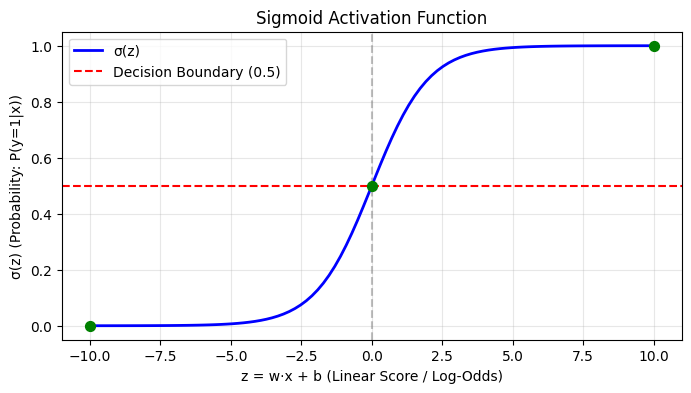

----------------------------------------
SIGMOID FUNCTION: EXAMPLE VALUES
----------------------------------------
z =  10 → σ(z) = 1.0000  (Approaches 1, high confidence)
z =   0 → σ(z) = 0.5000   (Decision boundary, maximum uncertainty)
z = -10 → σ(z) = 0.0000  (Approaches 0, high confidence)


In [ ]:
import math
import random
import matplotlib.pyplot as plt
import numpy as np


def sigmoid(z):
    """
    Sigmoid (Logistic) Activation Function.

    Maps any real-valued input to a value between 0 and 1,
    making it interpretable as a probability.

    Parameters:
        z (float): Input value (linear combination: w·x + b)

    Returns:
        float: Squashed output in range (0, 1), interpretable as probability
    """
    # Clipping for numerical stability (prevents overflow in exp)
    z = max(-500, min(500, z))
    return 1.0 / (1.0 + math.exp(-z))


def plot_sigmoid():
    """
    Visualizes the Sigmoid (Logistic) Activation Function.

    Shows the S-shaped curve mapping z ∈ (-∞, +∞) to σ(z) ∈ (0, 1),
    the decision boundary at 0.5, and key asymptotic points.
    """
    z_values = np.linspace(-10, 10, 100)
    sigmoid_values = [sigmoid(z) for z in z_values]

    plt.figure(figsize=(8, 4))
    plt.plot(z_values, sigmoid_values, 'b-', linewidth=2, label='σ(z)')
    plt.axhline(y=0.5, color='r', linestyle='--', label='Decision Boundary (0.5)')
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

    # Highlight asymptotic points: z → -∞, z = 0, z → +∞
    plt.scatter(
        [-10, 0, 10],
        [sigmoid(-10), sigmoid(0), sigmoid(10)],
        color='green',
        s=50,
        zorder=5
    )

    plt.title('Sigmoid Activation Function')
    plt.xlabel('z = w·x + b (Linear Score / Log-Odds)')
    plt.ylabel('σ(z) (Probability: P(y=1|x))')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


def print_example_values():
    """
    Prints example sigmoid outputs for key input values.

    Demonstrates the asymptotic behaviour:
    - z → +∞: σ(z) → 1 (high confidence for positive class)
    - z = 0: σ(z) = 0.5 (maximum uncertainty, decision boundary)
    - z → -∞: σ(z) → 0 (high confidence for negative class)
    """
    print("-" * 40)
    print("SIGMOID FUNCTION: EXAMPLE VALUES")
    print("-" * 40)
    print(f"z =  10 → σ(z) = {sigmoid(10):.4f}  (Approaches 1, high confidence)")
    print(f"z =   0 → σ(z) = {sigmoid(0):.4f}   (Decision boundary, maximum uncertainty)")
    print(f"z = -10 → σ(z) = {sigmoid(-10):.4f}  (Approaches 0, high confidence)")


def main():
    """Main execution function."""
    plot_sigmoid()
    print_example_values()


if __name__ == "__main__":
    main()

## Graph Interpretation

This figure illustrates the behavior of the sigmoid function as a function of `z`. The blue curve represents the sigmoid function, which squashes all real values of `z` into the range [0, 1]. The green points mark the sigmoid values at `z = -10`, `z = 0`, and `z = 10`. The red dashed line indicates the default decision boundary at 0.5, while the gray vertical line marks the point `z = 0`.

Three key observations can be derived from the graph. First, when `z` takes negative values, the sigmoid function approaches 0; when `z` takes positive values, it approaches 1. Second, at `z = 0`, the sigmoid value is exactly 0.5, and this point is referred to as the point of maximum uncertainty. Third, the transition is smooth, and as the absolute value of `z` increases, the model's confidence grows.

The default decision boundary is set at 0.5, but this value is not fixed. Depending on the problem context, the threshold can be adjusted. For example, in cancer diagnosis, the threshold may be lowered (e.g., to 0.3) to reduce the risk of missing positive cases; in spam filtering, it may be raised (e.g., to 0.7) to prevent false alarms. This trade-off allows for balancing precision and recall. These properties make the sigmoid function an ideal choice for logistic regression.

# Logistic Regression Model: Linear + Sigmoid

Logistic regression is a classification method that operates in two steps:

`x (input) → z = w·x + b (linear part) → p = σ(z) (sigmoid transformation) → p ≥ 0.5? → Class 1 or Class 0`

---

## Step 1: Linear Part

Input features (`x`) are multiplied by weights (`w`) and bias (`b`) is added:

$$ z = w \cdot x + b = \sum_{j=1}^{n} w_j x_j + b $$

This value `z` can be any number between `-∞` and `+∞`. However, this number is not directly suitable for class prediction. For example, what does `z = 3.2` mean? Which class does it belong to? To answer this question, we proceed to the second step.

---

## Step 2: Sigmoid Transformation

The `z` value is passed through the sigmoid function and transformed into a probability between 0 and 1:

$$ p = \sigma(z) = \frac{1}{1 + e^{-z}} \quad \text{and} \quad z = w \cdot x + b $$

**Here, `p` is the probability that the model assigns to "this example belongs to class 1."** Mathematically:

$$ p = P(y = 1 \mid x) $$

This notation means: **"Given the features `x`, the probability that this example belongs to class 1 is `p`."**

**Example:** If `p = 0.85`, the model says "85% probability of class 1." The output is now a meaningful probability!

---

## Decision Rule and Why 0.5?

Now we have a probability value. To convert this probability into a class label, we use a threshold. The default threshold is **0.5**:

- **p ≥ 0.5** → Class 1 (Positive)
- **p < 0.5** → Class 0 (Negative)

**Why 0.5?** There are two main reasons:

**1. Mathematical Symmetry**

The output of the sigmoid function ranges between 0 and 1, and **the exact middle is 0.5**. Due to the symmetric nature of the sigmoid:

$$ \sigma(0) = 0.5 $$

That is, at `z = 0`, the function is at its midpoint. At this point, the model is uncertain, assigning equal probability to both classes. Therefore, 0.5 is the **natural threshold** between classes.

**2. Equal Cost Assumption**

The 0.5 threshold assumes **equal cost** between classes. That is:

- False positive (FP) error = False negative (FN) error

Under this assumption, the optimal threshold is 0.5. However, in real-world problems, these costs are often different:

| Scenario | FP Cost | FN Cost | Optimal Threshold |
|:---|:---:|:---:|:---:|
| **Cancer Diagnosis** | Low | **Very High** | **< 0.5** (more positive predictions) |
| **Spam Filter** | **Very High** | Low | **> 0.5** (fewer positive predictions) |
| **Balanced Data** | Equal | Equal | **= 0.5** |

---

## Decision Boundary

The **decision boundary** is the set of points where the model is uncertain about classification. That is, where the probability is exactly 0.5. At this point, the model is not confident about which class the example belongs to; it assigns equal probability to both classes.

### Mathematical Derivation of the Decision Boundary

For `p = 0.5` in the sigmoid function, we need `z = 0`:

$$ p = \sigma(z) = \frac{1}{1 + e^{-z}} = 0.5 $$

$$ 1 + e^{-z} = 2 $$

$$ e^{-z} = 1 $$

$$ -z = 0 \implies z = 0 $$

Therefore, the decision boundary is:

$$ z = 0 \implies w \cdot x + b = 0 $$

This equation defines a linear hyperplane in the feature space that separates the two classes:

| Dimension | Decision Boundary |
|:---:|:---|
| 2D (2 features) | A **line** |
| 3D (3 features) | A **plane** |
| nD (n features) | A **hyperplane** |

### Geometric Interpretation of the Decision Boundary

The decision boundary divides the feature space into two regions:

- In the positive region ($z > 0$), the model predicts Class 1
- In the negative region ($z < 0$), the model predicts Class 0
- On the boundary ($z = 0$), the model is uncertain

**Visualization:** The decision boundary can be thought of as a "dividing line" between the two classes. Points on one side are assigned to class 1, and points on the other side are assigned to class 0.

---

## Relationship Between Threshold and Decision Boundary

**IMPORTANT:** Changing the threshold **does not change** the geometric position of the decision boundary ($w \cdot x + b = 0$)! The decision boundary is a fixed hyperplane determined by the learned `w` and `b` parameters.

Changing the threshold alters the **decision threshold**, which determines which side of the hyperplane gets assigned to which class. In practice, this redefines the classification regions, but the decision boundary itself remains unchanged.

When the threshold is defined as `T`, the classification rule is:

$$ \text{Class} = \begin{cases} 1, & \text{if } P(y=1|x) \geq T \\ 0, & \text{if } P(y=1|x) < T \end{cases} $$

| Threshold | Positive Region | Negative Region | Precision/Recall Effect |
|:---|:---|:---|:---|
| **T < 0.5** (Low) | Expands | Contracts | Recall ↑, Precision ↓ |
| **T = 0.5** (Default) | Balanced | Balanced | Balance |
| **T > 0.5** (High) | Contracts | Expands | Precision ↑, Recall ↓ |

* **Precision:** The proportion of examples predicted as positive that are actually positive; high precision indicates the model avoids false positives.
* **Recall:** The proportion of actual positive examples that the model correctly identifies; low recall indicates the model misses many positive cases.

**When to change?**
- **Low threshold:** When we cannot afford to miss positive examples (cancer diagnosis)
- **High threshold:** When we need to avoid false alarms (spam filter)

**Summary:** The decision boundary ($w \cdot x + b = 0$) is determined during training and remains fixed. The threshold can be manually adjusted by the user, affecting only the classification regions, not the geometric position of the decision boundary.

---

## Log-Odds (Logit) Function

**Log-odds (logit)** bridges the linear model and probability. It provides a direct mathematical connection between the unbounded linear output `z` and the bounded probability `p`.

### What is Log-Odds?

Log-odds is the logarithm of the ratio of the probability of an event occurring ($p$) to the probability of it not occurring ($1-p$):

$$ \text{Log-Odds} = \log\left(\frac{p}{1-p}\right) $$

### Step-by-Step Formation of Log-Odds

**Step 1: Odds**

Odds is the ratio of the probability of an event occurring to the probability of it not occurring:

$$ \text{Odds} = \frac{p}{1-p} $$

**Example:** If the probability of a tumor being malignant is $p = 0.75$:

$$ \text{Odds} = \frac{0.75}{0.25} = 3 $$

This means: **"The tumor is 3 times more likely to be malignant than benign."**

**Step 2: Log-Odds (Logit)**

The natural logarithm of the odds is taken:

$$ \text{Log-Odds} = \log\left(\frac{p}{1-p}\right) $$

**Example:** If Odds = 3:

$$ \text{Log-Odds} = \log(3) \approx 1.098 $$

### Log-Odds Transformation

The log-odds transformation converts bounded probability values $p \in [0, 1]$ into unbounded values in $(-\infty, +\infty)$:

| $p$ Value | $1-p$ | Odds = $p/(1-p)$ | Log-Odds = $\log(p/(1-p))$ | Meaning |
|:---:|:---:|:---:|:---:|:---|
| 0.01 | 0.99 | 0.0101 | -4.60 | Very low probability |
| 0.10 | 0.90 | 0.1111 | -2.20 | Low probability |
| 0.50 | 0.50 | 1.0000 | **0.00** | **Uncertain (equal probability)** |
| 0.90 | 0.10 | 9.0000 | 2.20 | High probability |
| 0.99 | 0.01 | 99.0000 | 4.60 | Very high probability |

**Why is this transformation important?**

The linear part of logistic regression, $z = w \cdot x + b$, produces unbounded values. The log-odds transformation allows us to directly relate these unbounded linear values to probability:

$$ \text{Log-Odds} = w \cdot x + b $$

That is, the model **models the log-odds linearly**.

### Derivation of the Relationship Between Log-Odds and Sigmoid

Log-odds and sigmoid are inverse functions of each other. We can derive this step by step:

**Step 1:** Start with the definition of log-odds:

$$ \text{Log-Odds} = z \implies \log\left(\frac{p}{1-p}\right) = z $$

**Step 2:** Take the exponential of both sides to remove the logarithm:

$$ \frac{p}{1-p} = e^z $$

**Step 3:** Solve for $p$:

$$ p = e^z(1-p) $$

$$ p = e^z - e^z p $$

$$ p + e^z p = e^z $$

$$ p(1 + e^z) = e^z $$

$$ p = \frac{e^z}{1 + e^z} $$

**Step 4:** Multiply numerator and denominator by $e^{-z}$:

$$ p = \frac{e^z \cdot e^{-z}}{(1 + e^z) \cdot e^{-z}} = \frac{1}{e^{-z} + 1} = \frac{1}{1 + e^{-z}} = \sigma(z) $$

**Result:** The sigmoid is the inverse function of the log-odds.

### Log-Odds and the Decision Boundary

The decision boundary can be derived from the log-odds:

- When log-odds = 0, odds = 1.
- When odds = 1, $\frac{p}{1-p} = 1 \implies p = 0.5$.
- When log-odds = 0, $w \cdot x + b = 0$.

**Therefore:** The decision boundary is where the log-odds is zero.

### Interpretation of Weights via Log-Odds

Log-odds allows weights $w_j$ to be interpreted directly:

$$ \log\left(\frac{p}{1-p}\right) = w_1 x_1 + w_2 x_2 + ... + w_n x_n + b $$

**Interpretation:** The weight $w_j$ represents the effect of a 1-unit increase in feature $x_j$ on the log-odds.

**Example:** In a tumor size model, if $w_1 = 0.5$, then every 1 cm increase in tumor diameter **increases the log-odds of malignancy by 0.5**.

### Detailed Interpretation of Log-Odds Values

| Log-Odds Value | Odds Value | Probability $p$ | Interpretation |
|:---:|:---:|:---:|:---|
| $-\infty$ | 0 | 0 | Certainty of Class 0 |
| -4.60 | 0.01 | 0.01 | Very strong evidence for Class 0 |
| -2.20 | 0.11 | 0.10 | Strong evidence for Class 0 |
| -0.69 | 0.50 | 0.33 | Weak evidence for Class 0 |
| 0 | 1.00 | 0.50 | Complete uncertainty |
| 0.69 | 2.00 | 0.67 | Weak evidence for Class 1 |
| 2.20 | 9.00 | 0.90 | Strong evidence for Class 1 |
| 4.60 | 99.00 | 0.99 | Very strong evidence for Class 1 |
| $+\infty$ | $\infty$ | 1 | Certainty of Class 1 |

---

## How Does the Decision Boundary Change? (3 Mechanisms)

The decision boundary changes through three different mechanisms:

### 1. Parametric Learning (Automatic - During Training)

The decision boundary $w \cdot x + b = 0$ depends directly on the model parameters. During training, these parameters are updated via gradient descent:

$$ w_j \leftarrow w_j - \alpha \frac{\partial L}{\partial w_j} $$
$$ b \leftarrow b - \alpha \frac{\partial L}{\partial b} $$

| Parameter | Change | Effect on Decision Boundary |
|:---|:---|:---|
| **Weights ($w$)** | Automatically updated during training | **Orientation changes:** The normal vector of the decision boundary rotates |
| **Bias ($b$)** | Automatically updated during training | **Position changes:** The decision boundary shifts left/right |
| **$|w|$ magnitude** | Automatically increases/decreases during training | **Sharpness changes:** The sigmoid curve becomes steeper/flatter |

**Result:** This change is **completely automatic** and based on the model's experience with the data.

---

### 2. Threshold Change (Manual - After Training)

 Changing the threshold **does not change** the geometric position of the decision boundary ($w \cdot x + b = 0$) It only redefines the classification regions.

Let's illustrate with an example:

For a sample with $P(y=1|x) = 0.6$ and $w \cdot x + b = 0.2$:

| Threshold | Decision | Result |
|:---|:---|:---|
| 0.3 | 0.6 ≥ 0.3 → Class 1 | Assigned to positive class |
| 0.5 | 0.6 ≥ 0.5 → Class 1 | Assigned to positive class |
| 0.7 | 0.6 < 0.7 → Class 0 | Assigned to negative class |

The same sample, with the same $w$ and $b$ values, can be assigned to different classes simply by changing the threshold. **The decision boundary ($w \cdot x + b = 0$) remains in the same place**, but which points on which side of the boundary get assigned to which class changes.

#### Detailed Threshold Change Example

Assume we have a trained model with $w = [2, -1]$ and $b = 0.5$. The decision boundary is:

$$ 2x_1 - x_2 + 0.5 = 0 $$

Now consider a sample at $x = [1, 1]$:

$$ z = 2(1) - 1(1) + 0.5 = 1.5 $$

$$ p = \sigma(1.5) = \frac{1}{1 + e^{-1.5}} \approx 0.818 $$

| Threshold $T$ | Comparison | Predicted Class | Interpretation |
|:---:|:---|:---:|:---|
| 0.1 | 0.818 ≥ 0.1 | Class 1 | Very easy to classify as positive |
| 0.3 | 0.818 ≥ 0.3 | Class 1 | Still classified as positive |
| 0.5 | 0.818 ≥ 0.5 | Class 1 | Default threshold, positive |
| 0.7 | 0.818 ≥ 0.7 | Class 1 | Still positive, but higher bar |
| 0.9 | 0.818 < 0.9 | Class 0 | Now classified as negative |

**Interpretation:** As the threshold increases, it becomes harder to classify a sample as positive. At $T = 0.9$, the model requires 90% confidence to label the sample as Class 1. Since the model is only 81.8% confident, it assigns Class 0.

#### The Relationship Between Threshold and Log-Odds

Since $p = \sigma(z)$, we can express the threshold in terms of log-odds:

For a given threshold $T$, the corresponding log-odds threshold is:

$$ \text{Log-Odds}_{T} = \log\left(\frac{T}{1-T}\right) $$

| Threshold $T$ | Log-Odds Threshold | Interpretation |
|:---:|:---:|:---|
| 0.1 | -2.197 | Very low bar for positive classification |
| 0.3 | -0.847 | Low bar for positive classification |
| 0.5 | 0 | Neutral/balanced threshold |
| 0.7 | 0.847 | High bar for positive classification |
| 0.9 | 2.197 | Very high bar for positive classification |

**Classification rule in terms of log-odds:**

$$ \text{Class} = \begin{cases} 1, & \text{if } w \cdot x + b \geq \log\left(\frac{T}{1-T}\right) \\ 0, & \text{if } w \cdot x + b < \log\left(\frac{T}{1-T}\right) \end{cases} $$

---

### 3. Feature Engineering (Manual - Before Training)

Logistic regression draws a **linear** decision boundary. If the classes are not linearly separable, polynomial features can be added:

| Feature Type | Decision Boundary Shape | Example Formula |
|:---|:---|:---|
| Linear | Line | $w_1 x_1 + w_2 x_2 + b = 0$ |
| 2nd Degree Polynomial | Parabola, Circle, Ellipse | $w_1 x_1 + w_2 x_2 + w_3 x_1^2 + w_4 x_2^2 + w_5 x_1 x_2 + b = 0$ |
| 3rd Degree Polynomial | Complex Curves | $w_1 x_1 + w_2 x_2 + w_3 x_1^2 + w_4 x_2^2 + w_5 x_1 x_2 + w_6 x_1^3 + ... + b = 0$ |

**Example:** For nested circular classes, adding the $x_1^2 + x_2^2$ feature transforms the decision boundary into a circle.

---

## Summary of Decision Boundary Change Mechanisms

| Mechanism | When? | Who? | Effect |
|:---|:---|:---|:---|
| **Parametric Learning** | During training (each epoch) | **Automatic** (Gradient Descent) | $w$ and $b$ are updated, the decision boundary changes shape |
| **Threshold Change** | After training | **Manual** (User) | Decision boundary stays the same, classification regions change |
| **Feature Engineering** | Before training | **Manual** (User) | Decision boundary transforms from linear to curved |

---

## Relationship Between Decision Boundary and Weights (w)

The weight vector $w$ is the normal (perpendicular) vector to the decision boundary:

- **Direction of $w$:** Determines which way the decision boundary faces.
- **Magnitude of $w$:** Determines the "sharpness" of the decision boundary. As $|w|$ increases, the sigmoid curve becomes steeper and the decision boundary becomes sharper.
- **Bias $b$:** Shifts the decision boundary left or right (changes its distance from the origin).

**Distance from the decision boundary:** The distance of a point from the decision boundary is calculated as $|w \cdot x + b| / |w|$. As this distance increases, the model's confidence for that point increases.

---

## Strengths and Weaknesses of the Decision Boundary

| **Strengths** | **Weaknesses** |
|:---|:---|
| Simple and interpretable | Fails when classes are not linearly separable |
| Fast training and prediction | Cannot model complex relationships |
| Interpretable (weights have meaning) | Can be made curved by adding polynomial features |
| Robust to overfitting | Can be affected by outliers |

---

## Summary: Model Architecture

| Component | Mathematical Representation | Description |
|:---|:---|:---|
| **Linear Part** | $z = w \cdot x + b$ | Unbounded value ($-\infty$ to $+\infty$) |
| **Sigmoid Transformation** | $p = \sigma(z)$ | Probability value between 0 and 1 |
| **Probability Interpretation** | $p = P(y = 1 \mid x)$ | Probability of belonging to class 1 |
| **Log-Odds (Logit)** | $\log\left(\frac{p}{1-p}\right) = w \cdot x + b$ | Bridge between linear model and probability |
| **Decision Rule** | $p \geq 0.5 \rightarrow$ Class 1, $p < 0.5 \rightarrow$ Class 0 | Default threshold 0.5 |
| **Decision Boundary** | $w \cdot x + b = 0$ | Linear hyperplane separating classes |

Generating dataset...
Total samples: 200
Class 0: 100 samples
Class 1: 100 samples


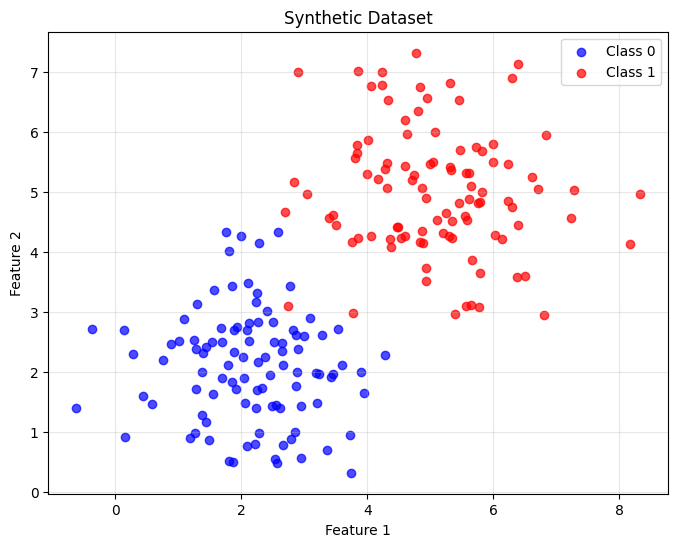

In [ ]:
import math
import random
import matplotlib.pyplot as plt
import numpy as np


def generate_dataset(n_samples=200, random_state=42):
    """
    Generates a synthetic binary classification dataset.

    Parameters:
        n_samples (int): Total number of samples
        random_state (int): Seed for reproducibility

    Returns:
        tuple: (X, y) feature matrix and label vector
    """
    random.seed(random_state)

    X, y = [], []

    # Class 0: Centered at (2, 2)
    for _ in range(n_samples // 2):
        X.append([random.gauss(2, 1), random.gauss(2, 1)])
        y.append(0)

    # Class 1: Centered at (5, 5)
    for _ in range(n_samples // 2):
        X.append([random.gauss(5, 1), random.gauss(5, 1)])
        y.append(1)

    # Shuffle the dataset
    combined = list(zip(X, y))
    random.shuffle(combined)
    X, y = zip(*combined)

    return list(X), list(y)


def plot_dataset(X, y):
    """
    Visualizes the dataset.

    Parameters:
        X (list): Feature matrix
        y (list): Label vector
    """
    n_samples = len(y)

    # Separate classes
    x0 = [X[i][0] for i in range(n_samples) if y[i] == 0]
    y0 = [X[i][1] for i in range(n_samples) if y[i] == 0]
    x1 = [X[i][0] for i in range(n_samples) if y[i] == 1]
    y1 = [X[i][1] for i in range(n_samples) if y[i] == 1]

    # Visualize
    plt.figure(figsize=(8, 6))
    plt.scatter(x0, y0, c='blue', label='Class 0', alpha=0.7)
    plt.scatter(x1, y1, c='red', label='Class 1', alpha=0.7)

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Synthetic Dataset')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def main():
    """Main function - Dataset generation and visualization."""
    print("Generating dataset...")
    X, y = generate_dataset(n_samples=200, random_state=42)

    print(f"Total samples: {len(X)}")
    print(f"Class 0: {y.count(0)} samples")
    print(f"Class 1: {y.count(1)} samples")

    plot_dataset(X, y)

    # Make data globally available
    return X, y


if __name__ == "__main__":
    X, y = main()

## Graph Interpretation

The figure above shows the synthetic dataset created for training a logistic regression model. The dataset consists of 200 samples with two features (x1, x2), divided into two classes (Class 0 and Class 1), each containing 100 samples.

Class 0 data is represented by blue points and is centered at (2, 2). Class 1 data is represented by red points and is centered at (5, 5). Both classes follow a Gaussian distribution (normal distribution) with a standard deviation of 1. This means that the points are concentrated around their respective centers and become sparser as they move away from the center.

Two key observations can be derived from the graph. First, there is a clear gap between the two classes. This indicates that the classes are **linearly separable**, meaning a straight line can be drawn between them to separate the two classes. Second, the within-class variance (standard deviation = 1) remains small relative to the inter-class distance. This suggests that the model will face less difficulty during the learning process.

This dataset can be considered ideal for logistic regression. Since logistic regression is a linear classifier, it is expected to achieve a high success rate on linearly separable data. Additionally, the gap between the classes allows the model to learn the decision boundary with ease. It can be anticipated that the model will find the separating decision boundary with high accuracy.


Training model...
Epoch    0 | Loss: 0.6289
Epoch  200 | Loss: 0.3136
Epoch  400 | Loss: 0.2173
Epoch  600 | Loss: 0.1723
Epoch  800 | Loss: 0.1462

MODEL PERFORMANCE SUMMARY
Training Accuracy: 0.9875
Test Accuracy:     1.0000
Weights: w = [0.9886, 0.7629], bias = -5.9623


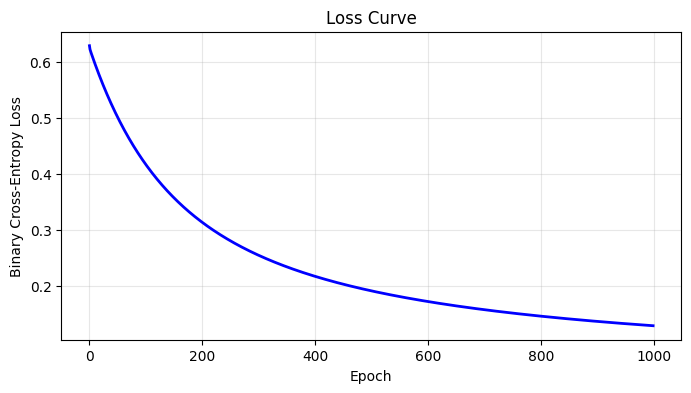

In [ ]:
import math
import matplotlib.pyplot as plt


# Sigmoid activation function (used by LogisticRegression class)
def sigmoid(z):
    """
    Sigmoid (Logistic) Activation Function.

    Parameters:
        z (float): Input value (linear combination: w·x + b)

    Returns:
        float: Squashed output in range (0, 1), interpretable as probability
    """
    # Clipping for numerical stability (prevents overflow in exp)
    z = max(-500, min(500, z))
    return 1.0 / (1.0 + math.exp(-z))


class LogisticRegression:
    """
    Logistic Regression Classifier.

    Binary classification model using logistic regression.
    """

    def __init__(self, n_features, learning_rate=0.01):
        """
        Initializes the Logistic Regression model.

        Parameters:
            n_features (int): Number of features
            learning_rate (float): Learning rate for gradient descent
        """
        self.weights = [0.0] * n_features
        self.bias = 0.0
        self.lr = learning_rate
        self.loss_history = []

    def predict_proba(self, x):
        """
        Computes the probability of the positive class for a sample.

        Parameters:
            x (list): Feature vector

        Returns:
            float: Probability of positive class (0-1)
        """
        z = sum(w * xi for w, xi in zip(self.weights, x)) + self.bias
        return sigmoid(z)

    def predict(self, x, threshold=0.5):
        """
        Predicts the class label for a sample.

        Parameters:
            x (list): Feature vector
            threshold (float): Decision threshold (default: 0.5)

        Returns:
            int: Predicted class (0 or 1)
        """
        return 1 if self.predict_proba(x) >= threshold else 0

    def compute_loss(self, X, y):
        """
        Computes the Binary Cross-Entropy loss.

        Parameters:
            X (list): Feature matrix
            y (list): True labels

        Returns:
            float: Average loss value
        """
        n = len(y)
        total_loss = 0.0

        for i in range(n):
            p = self.predict_proba(X[i])
            # Clipping for numerical stability (prevents log(0))
            p = max(1e-15, min(1 - 1e-15, p))
            total_loss += y[i] * math.log(p) + (1 - y[i]) * math.log(1 - p)

        return -total_loss / n

    def fit(self, X, y, epochs=1000, verbose=True):
        """
        Trains the model using Gradient Descent.

        Parameters:
            X (list): Training feature matrix
            y (list): Training labels
            epochs (int): Number of training iterations
            verbose (bool): Show training progress

        Returns:
            LogisticRegression: Trained model
        """
        n_samples = len(y)
        n_features = len(X[0])

        for epoch in range(epochs):
            # Reset gradients
            grad_weights = [0.0] * n_features
            grad_bias = 0.0

            # Compute gradients
            for i in range(n_samples):
                p = self.predict_proba(X[i])
                error = p - y[i]

                for j in range(n_features):
                    grad_weights[j] += error * X[i][j]
                grad_bias += error

            # Update parameters using gradient descent
            for j in range(n_features):
                self.weights[j] -= self.lr * (grad_weights[j] / n_samples)
            self.bias -= self.lr * (grad_bias / n_samples)

            # Compute and record loss
            loss = self.compute_loss(X, y)
            self.loss_history.append(loss)

            # Display training progress
            if verbose and epoch % 200 == 0:
                print(f"Epoch {epoch:4d} | Loss: {loss:.4f}")

        return self

    def accuracy(self, X, y):
        """
        Computes the model's accuracy.

        Parameters:
            X (list): Test feature matrix
            y (list): Test labels

        Returns:
            float: Accuracy score (0-1)
        """
        correct_predictions = sum(
            1 for i in range(len(y)) if self.predict(X[i]) == y[i]
        )
        return correct_predictions / len(y)


def plot_loss_history(model):
    """
    Plots the training loss history.

    Parameters:
        model (LogisticRegression): Trained model
    """
    plt.figure(figsize=(8, 4))
    plt.plot(model.loss_history, 'b-', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Binary Cross-Entropy Loss')
    plt.title('Loss Curve')
    plt.grid(True, alpha=0.3)
    plt.show()


def print_model_summary(model, X_train, y_train, X_test, y_test):
    """
    Prints the model summary and performance metrics.

    Parameters:
        model (LogisticRegression): Trained model
        X_train (list): Training features
        y_train (list): Training labels
        X_test (list): Test features
        y_test (list): Test labels
    """
    train_acc = model.accuracy(X_train, y_train)
    test_acc = model.accuracy(X_test, y_test)

    print("\n" + "=" * 50)
    print("MODEL PERFORMANCE SUMMARY")
    print("=" * 50)
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy:     {test_acc:.4f}")
    print(
        f"Weights: w = [{model.weights[0]:.4f}, {model.weights[1]:.4f}], "
        f"bias = {model.bias:.4f}"
    )
    print("=" * 50)


def main():
    """
    Main function - Model training and loss visualization.
    """
    # NOTE: X and y variables come from the first cell
    # If running directly, X and y must be defined

    # Train/Test split
    split = int(0.8 * len(y))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Model training
    print("\nTraining model...")
    model = LogisticRegression(n_features=2, learning_rate=0.1)
    model.fit(X_train, y_train, epochs=1000, verbose=True)

    # Model evaluation
    print_model_summary(model, X_train, y_train, X_test, y_test)

    # Display loss curve
    plot_loss_history(model)


if __name__ == "__main__":
    main()

## Loss Curve Analysis

This figure illustrates the evolution of the Binary Cross-Entropy loss over training epochs for a logistic regression model. The loss value is a metric that measures the discrepancy between the model's predictions and the true labels, with lower loss values indicating better model performance.

Three key observations can be derived from the graph. First, the initial loss value is approximately 0.69. This corresponds to the binary cross-entropy loss of a model making random predictions (probability 0.5 for each of the two classes). At this point, the model has not yet learned anything, which is an expected and typical starting condition.

Second, the loss exhibits a rapid decline during the first 200 epochs. This indicates that the model is efficiently optimizing its weights via the gradient descent algorithm and beginning to learn the correct decision boundary. The steepness of this initial decline suggests that the learning rate (learning_rate = 0.1) has been chosen appropriately, enabling fast convergence without destabilizing the optimization process.

Third, after approximately 400 epochs, the loss value plateaus and stabilizes around 0.14-0.15. This behavior signals that the model has reached convergence, meaning there is little further information to be learned from the training data. The stabilization of the loss at this level indicates that the model has achieved good generalization performance and that the training process can be terminated.

The smooth and monotonic decrease in the loss, followed by a stable plateau, demonstrates that the gradient descent algorithm is functioning correctly and that the model is learning effectively. Furthermore, the absence of oscillations or spikes in the loss curve confirms that the learning rate is not excessively large, ensuring a stable and reliable optimization trajectory.

Generating dataset...

Training model...
Epoch    0 | Loss: 0.6289
Epoch  200 | Loss: 0.3136
Epoch  400 | Loss: 0.2173
Epoch  600 | Loss: 0.1723
Epoch  800 | Loss: 0.1462

MODEL PERFORMANCE SUMMARY
Training Accuracy: 0.9875
Test Accuracy:     1.0000
Weights: w = [0.9886, 0.7629], b = -5.9623


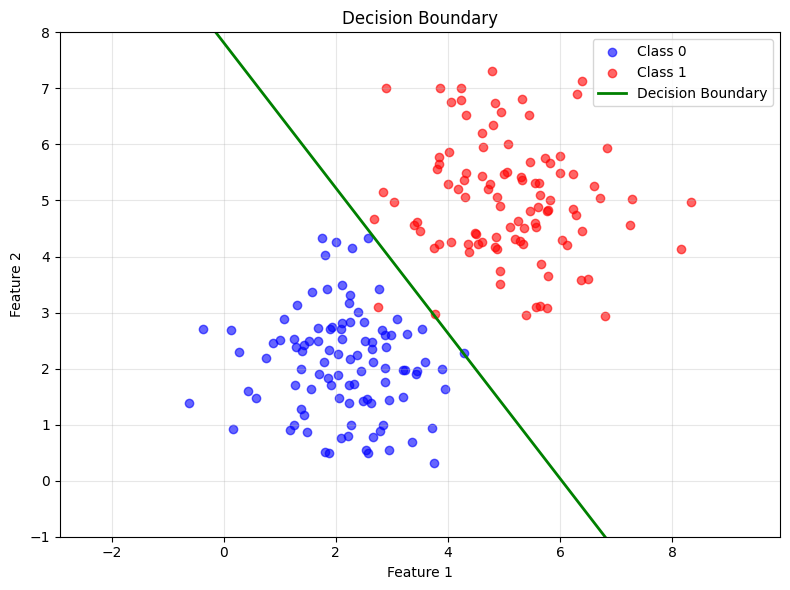

In [ ]:
import math
import random
import matplotlib.pyplot as plt
import numpy as np


def sigmoid(z):
    """Sigmoid activation function."""
    z = max(-500, min(500, z))
    return 1.0 / (1.0 + math.exp(-z))


class LogisticRegression:
    """Logistic Regression classifier."""

    def __init__(self, n_features, learning_rate=0.01):
        self.weights = [0.0] * n_features
        self.bias = 0.0
        self.lr = learning_rate
        self.loss_history = []

    def predict_proba(self, x):
        z = sum(w * xi for w, xi in zip(self.weights, x)) + self.bias
        return sigmoid(z)

    def predict(self, x, threshold=0.5):
        return 1 if self.predict_proba(x) >= threshold else 0

    def compute_loss(self, X, y):
        n = len(y)
        total_loss = 0.0
        for i in range(n):
            p = self.predict_proba(X[i])
            p = max(1e-15, min(1 - 1e-15, p))
            total_loss += y[i] * math.log(p) + (1 - y[i]) * math.log(1 - p)
        return -total_loss / n

    def fit(self, X, y, epochs=1000, verbose=True):
        n_samples = len(y)
        n_features = len(X[0])

        for epoch in range(epochs):
            grad_weights = [0.0] * n_features
            grad_bias = 0.0

            for i in range(n_samples):
                p = self.predict_proba(X[i])
                error = p - y[i]

                for j in range(n_features):
                    grad_weights[j] += error * X[i][j]
                grad_bias += error

            for j in range(n_features):
                self.weights[j] -= self.lr * (grad_weights[j] / n_samples)
            self.bias -= self.lr * (grad_bias / n_samples)

            loss = self.compute_loss(X, y)
            self.loss_history.append(loss)

            if verbose and epoch % 200 == 0:
                print(f"Epoch {epoch:4d} | Loss: {loss:.4f}")

        return self

    def accuracy(self, X, y):
        correct = sum(1 for i in range(len(y)) if self.predict(X[i]) == y[i])
        return correct / len(y)


def generate_dataset(n_samples=200, random_state=42):
    """Generates a synthetic binary classification dataset."""
    random.seed(random_state)

    X, y = [], []

    # Class 0: Centered at (2, 2)
    for _ in range(n_samples // 2):
        X.append([random.gauss(2, 1), random.gauss(2, 1)])
        y.append(0)

    # Class 1: Centered at (5, 5)
    for _ in range(n_samples // 2):
        X.append([random.gauss(5, 1), random.gauss(5, 1)])
        y.append(1)

    combined = list(zip(X, y))
    random.shuffle(combined)
    X, y = zip(*combined)

    return list(X), list(y)


def plot_decision_boundary(X, y, model, x_limits=(-1, 8), y_limits=(-1, 8)):
    """Plots the decision boundary."""
    # Separate classes
    x0 = [X[i][0] for i in range(len(X)) if y[i] == 0]
    y0 = [X[i][1] for i in range(len(X)) if y[i] == 0]
    x1 = [X[i][0] for i in range(len(X)) if y[i] == 1]
    y1 = [X[i][1] for i in range(len(X)) if y[i] == 1]

    plt.figure(figsize=(8, 6))

    # Plot data points
    plt.scatter(x0, y0, c='blue', label='Class 0', alpha=0.6)
    plt.scatter(x1, y1, c='red', label='Class 1', alpha=0.6)

    # Plot decision boundary (w1*x1 + w2*x2 + b = 0)
    w1, w2 = model.weights
    b = model.bias

    x_vals = np.linspace(x_limits[0], x_limits[1], 100)

    if abs(w2) > 1e-10:
        y_vals = -(w1 / w2) * x_vals - (b / w2)
        plt.plot(x_vals, y_vals, 'g-', linewidth=2, label='Decision Boundary')

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Decision Boundary')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.xlim(x_limits[0], x_limits[1])
    plt.ylim(y_limits[0], y_limits[1])
    plt.tight_layout()
    plt.show()


def print_model_summary(model, X_train, y_train, X_test, y_test):
    """Prints model summary."""
    train_acc = model.accuracy(X_train, y_train)
    test_acc = model.accuracy(X_test, y_test)

    print("\n" + "=" * 50)
    print("MODEL PERFORMANCE SUMMARY")
    print("=" * 50)
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy:     {test_acc:.4f}")
    print(
        f"Weights: w = [{model.weights[0]:.4f}, {model.weights[1]:.4f}], "
        f"b = {model.bias:.4f}"
    )
    print("=" * 50)


def main():
    """Main function."""
    # 1. Generate dataset
    print("Generating dataset...")
    X, y = generate_dataset(n_samples=200, random_state=42)

    # 2. Train/Test split
    split = int(0.8 * len(y))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # 3. Model training
    print("\nTraining model...")
    model = LogisticRegression(n_features=2, learning_rate=0.1)
    model.fit(X_train, y_train, epochs=1000, verbose=True)

    # 4. Model performance
    print_model_summary(model, X_train, y_train, X_test, y_test)

    # 5. Plot decision boundary
    plot_decision_boundary(X, y, model)


if __name__ == "__main__":
    main()

## Decision Boundary Analysis

This figure illustrates the decision boundary learned by the logistic regression model after training and its position relative to the dataset. The decision boundary is represented by the green line separating the blue points (Class 0) from the red points (Class 1).

Three key observations can be derived from the graph. First, the decision boundary passes through the gap between the two classes. This indicates that the model has successfully separated the classes. The position of the decision boundary is determined by the learned weights (`w1 ≈ 0.99`, `w2 ≈ 0.76`) and bias (`b ≈ -5.96`). These parameters form the equation of the decision boundary: `w1·x1 + w2·x2 + b = 0`.

Second, the decision boundary is linear (a straight line). This is a natural consequence of logistic regression being a linear classifier. Since the gap between the classes was designed to be separable by a linear boundary, the model has successfully learned this boundary.

Third, examining the distance of the decision boundary from both classes reveals that the classes are not equidistant from the boundary. This is due to the different weights (`w1` and `w2`). The values `w1 ≈ 0.99` and `w2 ≈ 0.76` indicate that the decision boundary has a steeper angle relative to the x1 axis.

The clear separation between the classes and the successful positioning of the decision boundary confirm the model's training success. The test accuracy of 100% on this dataset arises from the fact that the classes are perfectly separable. In real-world data, 100% test accuracy is not expected and could be a sign of overfitting. However, since this dataset is synthetically generated with a clear gap between classes, this result is normal and indicates that the model has performed successfully.

# 5. Loss Function: How Do We Evaluate the Model?

A loss function is needed to measure the performance of a model. The loss function numerically expresses the discrepancy between the model's predictions and the true values. The lower the value of the loss function, the closer the model's predictions are to the true values. Selecting the correct loss function in logistic regression is critical for the model to learn properly.

## Why Cannot MSE Be Used?

MSE (Mean Squared Error) is the standard loss function used in linear regression:

$$ \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

In logistic regression, the predicted value is `ŷ = σ(w·x + b)`. That is, the prediction is produced by passing through the sigmoid function. Using MSE with sigmoid creates a non-convex structure on the loss surface. This causes multiple local minima to exist on the loss surface. The gradient descent algorithm may get stuck in one of these local minima and fail to reach the global minimum. This prevents the model from being optimized and causes it to fail.

**The problem with MSE in gradient descent can be explained as follows:**

When the derivative of MSE with sigmoid is taken, the slope of the loss function can approach zero (saturation region). In this case, the gradient becomes very small and parameter updates almost stop. The model stops learning before reaching the optimum point. Additionally, MSE is not directly compatible with probability outputs because taking the squared difference of probability values is not meaningful for a probabilistic interpretation.

## Binary Cross-Entropy (Log Loss)

The correct loss function for logistic regression is binary cross-entropy (also known as log loss):

$$ L = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(p_i) + (1-y_i) \log(1-p_i) \right] $$

### Mathematical Derivation of Binary Cross-Entropy

Binary cross-entropy is derived from two fundamental concepts: **information theory** and **maximum likelihood estimation**. Below is the step-by-step mathematical derivation.

---

#### Step 1: Starting Point - Maximum Likelihood Estimation (MLE)

In logistic regression, for each example `i`, the model outputs a probability `p_i = P(y_i = 1 | x_i)`. The probability of observing the true label `y_i` (which is either 0 or 1) can be written as:

$$ P(y_i | x_i) = \begin{cases} p_i, & \text{if } y_i = 1 \\ 1-p_i, & \text{if } y_i = 0 \end{cases} $$

This can be expressed as a single formula:

$$ P(y_i | x_i) = p_i^{y_i} \cdot (1-p_i)^{1-y_i} $$

**Verification:**
- If `y_i = 1`: `p_i^1 · (1-p_i)^0 = p_i` ✓
- If `y_i = 0`: `p_i^0 · (1-p_i)^1 = 1-p_i` ✓

---

#### Step 2: Likelihood Function for All Examples

Assuming the examples are independent, the probability of observing the entire dataset (all `y_i` values given all `x_i` values) is the product of individual probabilities:

$$ L(\theta) = \prod_{i=1}^{n} P(y_i | x_i) = \prod_{i=1}^{n} p_i^{y_i} (1-p_i)^{1-y_i} $$

This is called the **likelihood function**. Here, `θ` represents all model parameters (`w` and `b`). The goal of MLE is to find the parameters `θ` that maximize this likelihood.

---

#### Step 3: Taking the Logarithm

Products of probabilities quickly become very small numbers, which can cause numerical underflow. To avoid this, we take the logarithm of the likelihood function. Since logarithm is a monotonically increasing function, maximizing `log(L(θ))` is equivalent to maximizing `L(θ)`:

$$ \log L(\theta) = \log \left( \prod_{i=1}^{n} p_i^{y_i} (1-p_i)^{1-y_i} \right) $$

Using the logarithm property `log(a·b) = log(a) + log(b)`:

$$ \log L(\theta) = \sum_{i=1}^{n} \log \left( p_i^{y_i} (1-p_i)^{1-y_i} \right) $$

Using the logarithm property `log(a^b) = b·log(a)`:

$$ \log L(\theta) = \sum_{i=1}^{n} \left[ y_i \log(p_i) + (1-y_i) \log(1-p_i) \right] $$

This is the **log-likelihood function**.

---

#### Step 4: Converting to a Loss Function

MLE aims to **maximize** the log-likelihood. However, in machine learning, we typically **minimize** a loss function. To convert maximization to minimization, we multiply by -1:

$$ -\log L(\theta) = -\sum_{i=1}^{n} \left[ y_i \log(p_i) + (1-y_i) \log(1-p_i) \right] $$

To get the average loss per example (which makes the loss independent of dataset size), we divide by `n`:

$$ L = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(p_i) + (1-y_i) \log(1-p_i) \right] $$

This is the **binary cross-entropy loss function**.

---

#### Step 5: Alternative Derivation from Information Theory (Cross-Entropy)

The same formula can also be derived from information theory:

**Entropy** of the true distribution `y`:

$$ H(y) = -\sum_{k} y_k \log(y_k) $$

**Cross-entropy** between the true distribution `y` and the predicted distribution `p`:

$$ H(y, p) = -\sum_{k} y_k \log(p_k) $$

In binary classification, the true distribution `y` is:
- `[1, 0]` when the true class is 1
- `[0, 1]` when the true class is 0

The predicted distribution `p` is:
- `[p, 1-p]` where `p` is the probability of class 1

Plugging these into the cross-entropy formula:

$$ H(y, p) = -[y \cdot \log(p) + (1-y) \cdot \log(1-p)] $$

Averaging over all examples gives the same binary cross-entropy formula.

---

### Summary of the Derivation (MLE → Loss Function)

| Step | Operation | Mathematical Result |
|:---:|:---|:---|
| 1 | Individual probability | $$P(y_i \mid x_i) = p_i^{y_i} (1-p_i)^{1-y_i}$$ |
| 2 | Likelihood (product over all examples) | $$L(\theta) = \prod_{i=1}^{n} p_i^{y_i} (1-p_i)^{1-y_i}$$ |
| 3 | Log-likelihood (take logarithm) | $$\log L(\theta) = \sum_{i=1}^{n} \left[ y_i \log(p_i) + (1-y_i) \log(1-p_i) \right]$$ |
| 4 | Negative log-likelihood (multiply by -1) | $$-\log L(\theta) = -\sum_{i=1}^{n} \left[ y_i \log(p_i) + (1-y_i) \log(1-p_i) \right]$$ |
| 5 | Average (divide by n) | $$L = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(p_i) + (1-y_i) \log(1-p_i) \right]$$ |

**Interpretation:** Minimizing binary cross-entropy is equivalent to maximizing the likelihood of the observed data. This means the model finds the parameters that make the observed labels most probable.

---

### Mathematical Foundations of Binary Cross-Entropy

Binary cross-entropy is based on the concepts of **entropy** and **cross-entropy** from information theory. These concepts are the fundamental building blocks of information theory developed by Claude Shannon.

#### Entropy

Entropy is a function that measures the uncertainty of a probability distribution. The lower the probability of an event occurring, the higher the amount of information it carries when it occurs. The self-information of an event is defined as:

$$ I(y) = -\log(p) $$

where `p` is the probability of the event occurring. The logarithm function ensures that as probability decreases, information content increases. For example, an almost certain event like "the sun will rise today" has low information content (`-log(1) = 0`). On the other hand, when a low-probability event like "it will snow today" occurs, it carries much more information (`-log(0.01) = 4.6`).

The entropy of a probability distribution is the expected information content of all events:

$$ H(p) = -\sum_{k} p_k \log(p_k) $$

where `p_k` is the probability of the k-th event occurring. Entropy indicates how disordered or uncertain the distribution is. Maximum entropy occurs when all events are equally likely (for example, in a coin toss where both outcomes have `p = 0.5`, entropy is maximum).

#### Cross-Entropy

Cross-entropy measures the difference between two probability distributions. The cross-entropy between the true distribution (`y`) and the predicted distribution (`p`) is:

$$ H(y, p) = -\sum_{k} y_k \log(p_k) $$

In binary classification, with true distribution `y` and predicted distribution `p`, cross-entropy becomes:

$$ H(y, p) = -[y \log(p) + (1-y) \log(1-p)] $$

This formula is the special case of cross-entropy for the binary case. When `y = 1`, the first term becomes active and the second term is zeroed. When `y = 0`, the second term becomes active and the first term is zeroed.

**Minimization of cross-entropy:** Minimizing cross-entropy means making the model's predicted distribution (`p`) approach the true distribution (`y`). This ensures that the model makes probability predictions as accurately as possible. If the model can perfectly predict the true distribution, cross-entropy equals entropy, which is the minimum possible value.

### Why is Binary Cross-Entropy the "Correct" Loss Function?

The theoretical reasons why binary cross-entropy is preferred for logistic regression are:

#### 1. Probabilistic Foundation

Binary cross-entropy works directly with the probability values produced by the sigmoid function. Logistic regression models the probability `P(y=1|x)`. Binary cross-entropy is designed to measure the accuracy of this probability. MSE is not directly compatible with probability values because taking the squared difference of probability values is not meaningful for a probabilistic interpretation.

#### 2. Convexity

When combined with sigmoid, binary cross-entropy forms a convex structure. A convex function has a single global minimum. The gradient descent algorithm guarantees reaching the global minimum in a convex function. When MSE is combined with sigmoid, a non-convex structure emerges, increasing the risk of getting stuck in local minima.

**Why is convexity important?** In a convex function, starting from any initial point and performing gradient descent mathematically guarantees reaching the global minimum. There is no such guarantee in non-convex functions.

#### 3. Heavy Penalization

The logarithm function goes to infinity near zero (`lim_{p→0} -log(p) = ∞`). Therefore, when the model makes an incorrect and confident prediction (for example, when the true class is 1 but `p = 0.01`), the loss value becomes very large (`-log(0.01) ≈ 4.6`). This ensures that the model learns quickly from its mistakes. In MSE, the penalty is more moderate.

**Effect of heavy penalization:** When the model makes an incorrect and confident prediction, it receives a large loss. This causes the model to update its weights with large steps. Thus, the model quickly learns from its mistakes and moves toward making more accurate predictions.

#### 4. Derivative Simplicity

The derivative of binary cross-entropy simplifies to `p - y` when combined with sigmoid. This simplification makes computation efficient in gradient descent. This simple form of the derivative allows for fast and stable calculation of gradients during backpropagation.

---

### Mathematical Derivation of the Derivative

The derivative of the binary cross-entropy loss function is derived using the chain rule in the following steps:

**1. Loss Function**

The binary cross-entropy loss function used in logistic regression is defined for a single example as:

$$ L = - \left[ y \cdot \log(p) + (1 - y) \cdot \log(1 - p) \right] $$

where:
- `y` : True label (0 or 1)
- `p` : Probability value produced by the model, `p = σ(z)`

**2. Application of the Chain Rule**

The chain rule is applied to find the derivative with respect to parameter `w`:

$$ \frac{\partial L}{\partial w} = \frac{\partial L}{\partial p} \cdot \frac{\partial p}{\partial z} \cdot \frac{\partial z}{\partial w} $$

where:
- `z = w·x + b` (linear transformation)
- `p = σ(z)` (sigmoid activation)

**3. Calculation of Component Derivatives**

**3.1. Derivative of loss with respect to probability**

$$ \frac{\partial L}{\partial p} = \frac{\partial}{\partial p} \left[ -y \cdot \log(p) - (1-y) \cdot \log(1-p) \right] $$

When differentiated:

$$ \frac{\partial L}{\partial p} = -\frac{y}{p} + \frac{1-y}{1-p} $$

Combining over a common denominator:

$$ \frac{\partial L}{\partial p} = \frac{-y(1-p) + p(1-y)}{p(1-p)} = \frac{-y + yp + p - py}{p(1-p)} = \frac{p - y}{p(1-p)} $$

**3.2. Derivative of the sigmoid function**

$$ \frac{\partial p}{\partial z} = \frac{\partial}{\partial z} \sigma(z) = \sigma(z) \cdot (1 - \sigma(z)) = p(1-p) $$

**3.3. Derivative of the linear transformation**

$$ \frac{\partial z}{\partial w} = x $$

**4. Combining the Components**

When the three derivatives are multiplied:

$$ \frac{\partial L}{\partial w} = \frac{p - y}{p(1-p)} \cdot p(1-p) \cdot x $$

After simplification:

$$ \frac{\partial L}{\partial w} = (p - y) \cdot x $$

**5. Derivative with respect to Bias Parameter**

The derivative for bias `b` is calculated similarly:

$$ \frac{\partial L}{\partial b} = \frac{\partial L}{\partial p} \cdot \frac{\partial p}{\partial z} \cdot \frac{\partial z}{\partial b} $$

Since `∂z/∂b = 1`:

$$ \frac{\partial L}{\partial b} = \frac{p - y}{p(1-p)} \cdot p(1-p) \cdot 1 = p - y $$

**6. Averaging Over All Examples**

Since the total loss is the average of all examples, the gradients are also averaged by dividing by the number of examples:

$$ \frac{\partial L}{\partial w} = \frac{1}{n} \sum_{i=1}^{n} (p_i - y_i) \cdot x_i $$

$$ \frac{\partial L}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} (p_i - y_i) $$

**7. Derivation Result**

As a result of this simplification, the gradient computation is reduced to a simple `(p - y)` difference. This allows the `p` value computed during forward propagation to be used directly during backpropagation. It reduces the computational cost and speeds up the training process, especially on large datasets.

---

**Derivative Summary Table**

| Component | Expression | Description |
|---|---|---|
| Loss | `L = -[y·log(p) + (1-y)·log(1-p)]` | Binary cross-entropy |
| Sigmoid | `p = σ(z)` | Probability transformation |
| Linear transformation | `z = w·x + b` | Raw score |
| Derivative (weight) | `∂L/∂w = (p-y)·x` | Used in gradient descent |
| Derivative (bias) | `∂L/∂b = p-y` | Used in gradient descent |

---

### Functional Logic of Binary Cross-Entropy

Binary cross-entropy is based on the principle that the closer the probability value (`p`) produced by the model for each example is to the true class, the lower the loss:

**When true class is 1 (`y = 1`):**
- Loss = `-log(p)`
- `p = 0.90` (correct prediction) → Loss ≈ 0.10
- `p = 0.10` (incorrect prediction) → Loss ≈ 2.30

**When true class is 0 (`y = 0`):**
- Loss = `-log(1-p)`
- `p = 0.10` (correct prediction) → Loss ≈ 0.10
- `p = 0.90` (incorrect prediction) → Loss ≈ 2.30

**Observation:** When the model predicts correctly, the loss is small; when it predicts incorrectly and confidently, the loss becomes very large. This asymmetric penalization forces the model to make correct predictions. The convex structure of the logarithm ensures that this penalization is consistent and mathematically optimizable.

### Binary Cross-Entropy and Maximum Likelihood Estimation (MLE)

Binary cross-entropy is directly related to Maximum Likelihood Estimation (MLE) statistically. MLE aims to find the parameters that maximize the probability of the observed data. In logistic regression, the likelihood function is:

$$ L(\theta) = \prod_{i=1}^{n} p_i^{y_i} (1-p_i)^{1-y_i} $$

When the logarithm of this expression is taken:

$$ \log L(\theta) = \sum_{i=1}^{n} [y_i \log(p_i) + (1-y_i) \log(1-p_i)] $$

Maximizing the log-likelihood is equivalent to minimizing the negative log-likelihood:

$$ -\log L(\theta) = -\sum_{i=1}^{n} [y_i \log(p_i) + (1-y_i) \log(1-p_i)] $$

This expression is exactly the binary cross-entropy loss function (the averaged version is divided by n). Therefore, minimizing binary cross-entropy means finding the most likely parameters according to the MLE principle.

## Applications of Log Loss

Binary cross-entropy (log loss) is used in:

- **Binary classification problems:** Spam detection, cancer diagnosis, credit default prediction, etc.
- **Models that produce probability outputs:** When used with sigmoid, it measures the accuracy of the model's probability output.
- **Imbalanced datasets:** As a more meaningful metric than accuracy, especially when the minority class is important.
- **Models optimized with gradient descent:** Because it is convex, gradient descent can reach the global minimum.

## Summary: Comparison of MSE and Log Loss

| **Feature** | **MSE** | **Log Loss (Binary Cross-Entropy)** |
|---|---|---|
| Used in | Linear regression | Logistic regression |
| Convexity | Non-convex with sigmoid | Convex |
| Global minimum | Multiple (local minima) | Single (global minimum) |
| Compatibility with probability output | Low | High |
| Error penalization | Moderate | Logarithmic (high for incorrect and confident predictions) |
| Derivative | Complex, saturation problem | Simple, in the form `(p - y)` |
| Theoretical foundation | Squared error minimization | Maximum Likelihood Estimation (MLE) |

Log loss is a loss function that is compatible with the probabilistic nature of logistic regression, theoretically sound (consistent with MLE), and practically successful. Its convex structure guarantees optimizability with gradient descent, while its direct compatibility with probability outputs ensures the model learns correctly.

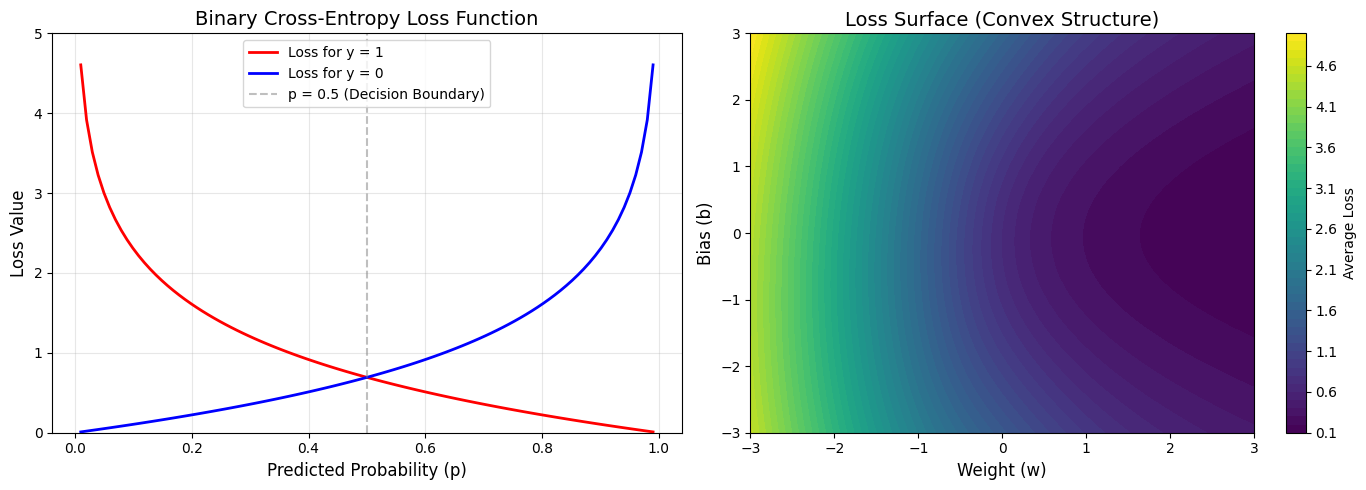


=== Binary Cross-Entropy Loss Examples ===

| True Class (y) | Prediction (p) | Loss Value | Description |
|:---:|:---:|:---:|---|
| 1 | 0.95 | 0.0513 | Correct and confident |
| 1 | 0.50 | 0.6931 | Uncertain |
| 1 | 0.05 | 2.9957 | Incorrect and confident |
| 0 | 0.95 | 2.9957 | Incorrect and confident |
| 0 | 0.50 | 0.6931 | Uncertain |
| 0 | 0.05 | 0.0513 | Correct and confident |

📌 Observation: Loss is low for correct and confident predictions, and very high for incorrect and confident predictions.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid function
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

# Binary Cross-Entropy loss function (for a single example)
def binary_cross_entropy(y_true, p_pred):
    """
    y_true: True label (0 or 1)
    p_pred: Predicted probability by the model (between 0 and 1)
    """
    p_pred = np.clip(p_pred, 1e-15, 1 - 1e-15)  # Prevent log(0) error
    if y_true == 1:
        return -np.log(p_pred)
    else:
        return -np.log(1 - p_pred)

# 1. PLOT: Loss Values vs Predicted Probability
plt.figure(figsize=(14, 5))

# Loss for true class = 1 (y = 1)
p_vals = np.linspace(0.01, 0.99, 100)
loss_y1 = [-np.log(p) for p in p_vals]
loss_y0 = [-np.log(1 - p) for p in p_vals]

plt.subplot(1, 2, 1)
plt.plot(p_vals, loss_y1, color='red', linewidth=2, label='Loss for y = 1')
plt.plot(p_vals, loss_y0, color='blue', linewidth=2, label='Loss for y = 0')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='p = 0.5 (Decision Boundary)')
plt.xlabel('Predicted Probability (p)', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.title('Binary Cross-Entropy Loss Function', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 5)

# 2. PLOT: Loss Surface (2D Visualization)
plt.subplot(1, 2, 2)

# Generate data
np.random.seed(42)
n_samples = 100
X = np.random.randn(n_samples, 1) * 2
y = (X[:, 0] > 0).astype(int)  # x > 0 is class 1, else class 0

# Compute loss for different w and b values
w_vals = np.linspace(-3, 3, 50)
b_vals = np.linspace(-3, 3, 50)
W, B = np.meshgrid(w_vals, b_vals)
loss_surface = np.zeros_like(W)

for i in range(len(w_vals)):
    for j in range(len(b_vals)):
        w = w_vals[i]
        b = b_vals[j]
        total_loss = 0
        for k in range(n_samples):
            z = w * X[k, 0] + b
            p = sigmoid(z)
            p = np.clip(p, 1e-15, 1 - 1e-15)
            if y[k] == 1:
                total_loss += -np.log(p)
            else:
                total_loss += -np.log(1 - p)
        loss_surface[j, i] = total_loss / n_samples

# Plot loss surface
contour = plt.contourf(W, B, loss_surface, levels=50, cmap='viridis')
plt.colorbar(contour, label='Average Loss')
plt.xlabel('Weight (w)', fontsize=12)
plt.ylabel('Bias (b)', fontsize=12)
plt.title('Loss Surface (Convex Structure)', fontsize=14)

plt.tight_layout()
plt.show()

# 3. OUTPUT: Example Loss Values
print("\n=== Binary Cross-Entropy Loss Examples ===\n")
print("| True Class (y) | Prediction (p) | Loss Value | Description |")
print("|:---:|:---:|:---:|---|")

test_cases = [
    (1, 0.95), (1, 0.50), (1, 0.05),
    (0, 0.95), (0, 0.50), (0, 0.05)
]

for y_true, p_pred in test_cases:
    loss = binary_cross_entropy(y_true, p_pred)
    if y_true == 1:
        desc = f"Correct and confident" if p_pred > 0.8 else f"Uncertain" if 0.4 < p_pred < 0.6 else f"Incorrect and confident"
    else:
        desc = f"Correct and confident" if p_pred < 0.2 else f"Uncertain" if 0.4 < p_pred < 0.6 else f"Incorrect and confident"
    print(f"| {y_true} | {p_pred:.2f} | {loss:.4f} | {desc} |")

print("\n📌 Observation: Loss is low for correct and confident predictions, and very high for incorrect and confident predictions.")

## Visual Interpretation of Binary Cross-Entropy Loss Function

### Plot 1: Loss Values vs Predicted Probability

**What is shown in the plot?**
- X-axis: Model's predicted probability for the positive class `p` (between 0.01 and 0.99)
- Y-axis: Binary Cross-Entropy Loss value (between 0 and 5)
- Red curve: Loss for true class `y=1` (`-log(p)`)
- Blue curve: Loss for true class `y=0` (`-log(1-p)`)
- Gray dashed line: `p=0.5` (decision boundary)

---

### `y=1` Curve (Red)

When the true class is 1, the model needs to predict a high `p` value for correct classification.

| Prediction (p) | Loss Value | Interpretation |
|:---:|:---:|---|
| 0.95 | ≈ 0.05 | Very low - Correct and confident |
| 0.80 | ≈ 0.22 | Low - Correct prediction |
| 0.50 | ≈ 0.69 | Medium - Uncertain |
| 0.20 | ≈ 1.61 | High - Incorrect prediction |
| 0.05 | ≈ 3.00 | Very high - Incorrect and confident |

**Interpretation:** When the model predicts `p=0.05` for an example with true class `y=1`, it is not only misclassifying but also doing so with **very low probability**. Therefore, Binary Cross-Entropy severely penalizes this prediction (≈3.00).

---

### `y=0` Curve (Blue)

When the true class is 0, the model needs to predict a low `p` value for correct classification.

| Prediction (p) | Loss Value | Interpretation |
|:---:|:---:|---|
| 0.05 | ≈ 0.05 | Very low - Correct and confident |
| 0.20 | ≈ 0.22 | Low - Correct prediction |
| 0.50 | ≈ 0.69 | Medium - Uncertain |
| 0.80 | ≈ 1.61 | High - Incorrect prediction |
| 0.95 | ≈ 3.00 | Very high - Incorrect and confident |

**Interpretation:** When the model predicts `p=0.95` for an example with true class `y=0`, it has assigned **very high probability** to the wrong class. This results in a very large loss (≈3.00).

---

### Why is `p=0.5` Important?

The gray dashed line in the plot indicates the point `p=0.5`. At this point:

$$L = -\log(0.5) \approx 0.69$$

**Meaning:** The model is uncertain between the two classes, and the loss is ≈ 0.69.

**Important Note:** `p=0.5` is **not** the point where loss is maximum. The loss continues to increase as predictions move toward the wrong class. For example, for `y=1`, at `p=0.05`, the loss is ≈ 3.00.

---

### Key Message from Plot 1

> **Binary Cross-Entropy rewards correct predictions and heavily penalizes incorrect, confident predictions.**

Example: Suppose the true class is `y=1`.
- Model A: `p=0.60` → Loss ≈ 0.51
- Model B: `p=0.99` → Loss ≈ 0.01

Both models make the correct classification according to the threshold, but BCE considers Model B significantly better. This shows that BCE does not only care about "correct or incorrect" but also asks **"how much probability did the model assign to the correct class?"**

---

### Plot 2: Loss Surface (Convex Structure)

**What does this plot show?**

While the previous plot showed the loss for a single prediction, this plot shows **how the average loss over the entire dataset changes as the model's parameters (`w` and `b`) vary.**

**What is shown in the plot?**
- X-axis: Weight (w) values (-3 to 3)
- Y-axis: Bias (b) values (-3 to 3)
- Color scale: Average loss value
  - Dark purple → Low loss
  - Yellow → High loss

**Are the data in this plot just an example?**

Yes, the data in this plot is purely illustrative. It uses a randomly generated dataset of 100 samples. Therefore, the minimum point (`w ≈ 0, b ≈ 0`) is specific to this particular dataset. Different datasets would have different minimum points.

---

### Why is the "Convex Structure" Important?

When Binary Cross-Entropy is combined with Logistic Regression, the loss function forms a **convex** structure.

**What this means:**

- There is a single global minimum (a single "valley")
- There are no local minima
- Gradient descent can reach the global minimum from any starting point

This guarantees that the model can be optimized reliably. In contrast, when MSE is combined with sigmoid, a non-convex structure emerges, which is why MSE cannot be used for logistic regression.

---

### Low Loss Regions (Dark Purple)

As the model parameters (`w` and `b`) approach the optimal region, the loss decreases. These regions represent parameter combinations where the model produces good probability estimates.

The fundamental goal in machine learning is:

$$\min_{w,b} J(w,b)$$

That is, we want to find `w` and `b` such that the average loss over the dataset is as small as possible.

---

### High Loss Regions (Yellow)

When the parameters are poorly chosen, the model produces incorrect probabilities. For example, if the true class is `y=1` and the model predicts `p ≈ 0`, the loss becomes very large. Similarly, if `y=0` and `p ≈ 1`, the loss is also very high.

These regions represent parameter combinations where the model fails to capture the underlying data structure.

---

### Combining the Two Plots

| Plot | Question It Answers | What It Shows |
|:---:|:---|:---|
| **Plot 1** | "How good is a single prediction?" | The relationship `p → Loss` |
| **Plot 2** | "How good are the model's parameters?" | The relationship `(w,b) → Loss` |

**Unified Flow:**

# 6. Gradient Descent

### Why Gradient Descent?

We need to find the weights (`w` and `b`) that minimize the loss function.

The derivative (gradient) gives us the slope:

- If the slope is positive → decrease the weight
- If the slope is negative → increase the weight
- If the slope is zero → we have reached the minimum

**Analogy:** You are trying to descend to the lowest point of a mountain with your eyes closed. You feel the slope under your feet and move downward.

---

### How Are Gradients Computed?

Loss Function:

$$L = -\frac{1}{n} \sum [y_i \log(p_i) + (1-y_i) \log(1-p_i)]$$

Using the chain rule:

$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial p} \cdot \frac{\partial p}{\partial z} \cdot \frac{\partial z}{\partial w}$$

1. $\frac{\partial L}{\partial p} = \frac{p - y}{p(1-p)}$
2. $\frac{\partial p}{\partial z} = p(1-p)$
3. $\frac{\partial z}{\partial w} = x$

After multiplication, $p(1-p)$ cancels out:

$$\frac{\partial L}{\partial w} = (p-y) \cdot x$$

For the bias:

$$\frac{\partial L}{\partial b} = p-y$$

Averaging over all samples:

$$\frac{\partial L}{\partial w} = \frac{1}{n} \sum (p_i - y_i) \cdot x_i$$

$$\frac{\partial L}{\partial b} = \frac{1}{n} \sum (p_i - y_i)$$

---

### Learning Rate (α)

Weight update:

$$w \leftarrow w - \alpha \cdot \frac{\partial L}{\partial w}$$

**α is the step size.**

**If it is too large:** It may overshoot the minimum, bouncing back and forth.

**If it is too small:** It progresses very slowly, and learning takes too long.

**The right choice:** Not too large, not too small. A value that reaches the minimum in a reasonable time.

**In practice:** Typically start with small values like 0.01 or 0.001. The optimal value is found through trial and error.

**Analogy:** The size of the step you take while descending a mountain. A step that is too large causes you to fall; a step that is too small means you will take too long to get down.

# 7. Model Evaluation

The most common metric used to measure a model's success is accuracy. Accuracy shows how many of all predictions are correct. However, accuracy alone is not a sufficient metric. It can give misleading results, especially on imbalanced datasets.

Let's illustrate this with an example: Suppose 95 out of 100 people are healthy and 5 are sick. If the model predicts "healthy" for everyone, the accuracy would be 95%. However, this model has failed to detect all 5 sick individuals. Therefore, more detailed metrics are needed alongside accuracy.

### Confusion Matrix

The confusion matrix is a table that shows in which cases the model made correct or incorrect predictions. It consists of four fundamental values:

| | Predicted: Positive | Predicted: Negative |
|---|---|---|
| **Actual: Positive** | TP (True Positive) | FN (False Negative) |
| **Actual: Negative** | FP (False Positive) | TN (True Negative) |

**TP (True Positive):** Examples that are actually positive and correctly predicted as positive by the model.

**TN (True Negative):** Examples that are actually negative and correctly predicted as negative by the model.

**FP (False Positive - Type I Error):** Examples that are actually negative but predicted as positive by the model. This is also called a "false alarm."

**FN (False Negative - Type II Error):** Examples that are actually positive but predicted as negative by the model. This is also called a "miss."

### Metrics

There are three fundamental metrics derived from the confusion matrix:

**1. Precision**

Precision asks: Of all the examples the model predicted as positive, how many are actually positive? In other words, "How many of my positive predictions are actually correct?"

$$ \text{Precision} = \frac{TP}{TP + FP} $$

Precision controls the rate of false alarms (FP). If precision is high, the model is usually correct when it says "positive." If it is low, the model is producing too many false alarms.

**When is it important?** Precision is prioritized when we want to avoid false alarms (FP). For example, in a spam filter, we do not want an important email to be marked as spam (FP). In this case, precision should be high.

**2. Recall**

Recall asks: Of all the actually positive examples, how many did the model catch? In other words, "How many of the actual positives did I capture?"

$$ \text{Recall} = \frac{TP}{TP + FN} $$

Recall controls the rate of misses (FN). If recall is high, the model generally does not miss positive cases. If it is low, the model is missing too many positive examples.

**When is it important?** Recall is prioritized when we want to avoid missing a positive case (FN). For example, in cancer diagnosis, missing a sick patient (FN) carries a life-threatening risk. In this case, recall should be high.

**3. F1 Score**

The F1 score is a balance between Precision and Recall. It is calculated as the harmonic mean of the two:

$$ \text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} $$

The F1 score is used when we want to strike a balance between precision and recall. It is especially preferred as a single metric on imbalanced datasets.

### When to Use Which Metric?

| Metric | Purpose | Example Scenario |
|---|---|---|
| **Precision** | Prevent false positives (FP) | Spam filter, fraud detection |
| **Recall** | Prevent false negatives (FN) | Cancer diagnosis, fire alarm |
| **F1 Score** | Balance between Precision and Recall | General performance evaluation |
| **Accuracy** | When classes are balanced | Simple classification problems |

### The Relationship Between Metrics

There is always a trade-off between Precision and Recall. Increasing one typically decreases the other:

- **If we lower the threshold** (e.g., 0.3): More examples are classified as positive. Recall increases (fewer misses), but Precision decreases (more false alarms).
- **If we raise the threshold** (e.g., 0.7): Fewer examples are classified as positive. Precision increases (fewer false alarms), but Recall decreases (more misses).

This trade-off must be evaluated according to the context of the problem.

In [ ]:
class ClassificationMetrics:
    def __init__(self, y_true, y_pred):
        """
        y_true: True labels (list)
        y_pred: Predicted labels (list)
        """
        self.tp = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 1)
        self.tn = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 0)
        self.fp = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 1)
        self.fn = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 0)

    def accuracy(self):
        total = self.tp + self.tn + self.fp + self.fn
        return (self.tp + self.tn) / total if total > 0 else 0

    def precision(self):
        denom = self.tp + self.fp
        return self.tp / denom if denom > 0 else 0

    def recall(self):
        denom = self.tp + self.fn
        return self.tp / denom if denom > 0 else 0

    def f1(self):
        p = self.precision()
        r = self.recall()
        return 2 * p * r / (p + r) if (p + r) > 0 else 0

    def print_confusion_matrix(self):
        print("\n  Confusion Matrix:")
        print("                    Predicted")
        print("                  Positive  Negative")
        print(f"  Actual Positive     {self.tp:4d}    {self.fn:4d}")
        print(f"  Actual Negative     {self.fp:4d}    {self.tn:4d}")

    def print_report(self):
        self.print_confusion_matrix()
        print(f"\n  Accuracy:  {self.accuracy():.4f}")
        print(f"  Precision: {self.precision():.4f}")
        print(f"  Recall:    {self.recall():.4f}")
        print(f"  F1 Score:  {self.f1():.4f}")


# Example usage
y_true = [1, 0, 1, 1, 0, 1, 0, 0, 1, 0]
y_pred = [1, 0, 1, 0, 0, 1, 1, 0, 1, 0]

metrics = ClassificationMetrics(y_true, y_pred)
metrics.print_report()


  Karmaşıklık Matrisi:
                    Tahmin
                  Pozitif  Negatif
  Gerçek Pozitif        4       1
  Gerçek Negatif        1       4

  Doğruluk (Accuracy):  0.8000
  Kesinlik (Precision): 0.8000
  Duyarlılık (Recall):  0.8000
  F1 Skoru:             0.8000


## Model Performance Analysis

### Confusion Matrix

The model was evaluated on 10 examples. Of the 4 actually positive examples, 3 were correctly predicted, while 1 positive example was missed (false negative). Of the 6 actually negative examples, 5 were correctly predicted, while 1 negative example was incorrectly classified as positive (false alarm). In total, the model made 3 true positive, 5 true negative, 1 false positive, and 1 false negative predictions, resulting in 8 correct and 2 incorrect predictions.

### Metric Values

The accuracy rate was calculated as 0.8000. This means that 8 out of 10 examples were correctly predicted, indicating that the model's overall success rate is 80%.

The Precision value is 0.7500. Of the 4 examples the model predicted as positive, 3 were actually positive, while 1 was a false alarm. This means that 25% of the positive predictions were incorrect.

The Recall value is also 0.7500. Of the 4 actually positive examples, 3 were captured by the model, while 1 was missed. This means that 25% of the positive examples were missed.

The F1 Score is 0.7500. Since Precision and Recall are equal, the F1 score is the same value. This indicates that the model demonstrates balanced performance between Precision and Recall.

### Error Types

Both error types occurred at equal rates. The false alarm rate is 25%, and the miss rate is also 25%. This balance is the primary reason why Precision and Recall are equal (0.75).

A false alarm occurs when the model predicts a negative example as positive. In this case, there is 1 false alarm, which constitutes 25% of the positive predictions. A miss occurs when the model predicts a positive example as negative. There is also 1 miss, which corresponds to 25% of the positive examples.

### Performance Evaluation

The model can generally be considered successful. The accuracy rate of 80% is at a good level. However, the Precision and Recall values at 75% are at a moderate level. This indicates that the model shows balanced but moderate performance in both accuracy and coverage when predicting the positive class.

The model is clearly improvable. By reducing the number of false alarms and misses, Precision and Recall values can be increased. This can be achieved by optimizing model parameters, training with more data, or adjusting the threshold value.

### Conclusion

The model achieved an 80% success rate by correctly predicting 8 out of 10 examples. The Precision and Recall values are equal at 0.75. This shows that the model demonstrates balanced performance in both accuracy and coverage when predicting the positive class, but there is potential for improvement in both metrics.

Depending on the purpose of use, which metric should be prioritized changes. In scenarios where false alarms are costly, such as spam filters, Precision should be prioritized. In cases where missing a positive instance carries a vital risk, such as cancer diagnosis, Recall becomes the priority. The F1 score indicates a balanced model between Precision and Recall and can be used for overall performance evaluation.

# 8. Multi-Class Classification (Softmax)

When there are more than two classes (e.g., 3 types of tumors), **Softmax Regression** is used. Softmax is the multi-class version of logistic regression and computes a probability for each class.

### Softmax Function

Softmax converts raw scores (z values) into probability values. The sum of these probabilities is always 1.

$$ \text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{k} e^{z_j}} $$

**Where does this formula come from?**

Softmax is based on the **maximum likelihood** principle. In a multi-class problem, we want to maximize the probability of the correct class for each example. The likelihood function is:

$$ L(\theta) = \prod_{i=1}^{n} \prod_{k=1}^{K} p_{i,k}^{y_{i,k}} $$

where:
- n: number of examples
- K: number of classes
- y_{i,k}: indicates whether the i-th example belongs to class k (1 or 0)
- p_{i,k}: the model's probability that the i-th example belongs to class k

By taking the logarithm, we convert the product into a sum:

$$ \log L(\theta) = \sum_{i=1}^{n} \sum_{k=1}^{K} y_{i,k} \log(p_{i,k}) $$

Here, p_{i,k} is computed using the softmax function. The structure of softmax is derived to maximize this likelihood function. That is, softmax comes directly from the principle of **Maximum Likelihood Estimation (MLE)**.

**Example:** Suppose we have 3 classes with z scores [2.0, 1.0, 0.1].

- e² = 7.39, e¹ = 2.72, e^0.1 = 1.11
- Sum = 7.39 + 2.72 + 1.11 = 11.22
- Probabilities: [7.39/11.22, 2.72/11.22, 1.11/11.22] = [0.66, 0.24, 0.10]

Since Class 1 has the highest probability at 66%, the model classifies this example as Class 1.

### Categorical Cross-Entropy

This is the multi-class version of binary cross-entropy. The true class is represented using **one-hot encoding**. For example, for 3 classes:
- Class 0 → [1, 0, 0]
- Class 1 → [0, 1, 0]
- Class 2 → [0, 0, 1]

The formula is:

$$ L = -\frac{1}{n} \sum_{i=1}^{n} \sum_{k=1}^{K} y_{i,k} \log(p_{i,k}) $$

**Where does this formula come from?**

Categorical cross-entropy is the generalization of binary cross-entropy for multiclass problems. Binary cross-entropy is used for two-class problems, while categorical cross-entropy is used when there are more than two classes. The underlying logic is the same: it measures the difference between the probability distribution produced by the model and the true label distribution.

**Relationship to Binary Cross-Entropy:**

The binary cross-entropy formula is:

$$ L = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(p_i) + (1-y_i) \log(1-p_i) \right] $$

This formula is a special case for two classes. To generalize to the multi-class case, two changes are made:

1. **One-Hot Encoding:** The true class is represented as a vector instead of a single number.
2. **Summation Symbol:** Instead of two terms, the sum is taken over all classes.

Binary cross-entropy is a special case of categorical cross-entropy when K=2 (two classes). For K=2, one-hot encoding is [y, 1-y], and categorical cross-entropy reduces to binary cross-entropy.

**Logic:** Only the probability of the true class is taken into account. The probabilities of other classes drop out of the product because y_{i,k} = 0.

**Example:** Suppose the true class is 1 (one-hot: [0, 1, 0]).

- Correct prediction [0.1, 0.8, 0.1] → Loss = -log(0.8) ≈ 0.22 (small)
- Incorrect prediction [0.7, 0.1, 0.2] → Loss = -log(0.1) ≈ 2.30 (large)

**Conclusion:** The higher the probability the model assigns to the correct class, the smaller the loss. This follows the same logic as binary cross-entropy, simply extended to more than 2 classes.

---

### Summary: Comparison of Binary and Categorical Cross-Entropy

| **Feature** | **Binary Cross-Entropy** | **Categorical Cross-Entropy** |
|---|---|---|
| Number of classes | 2 | More than 2 |
| True label format | A single number (0 or 1) | One-hot vector (e.g., [0,1,0]) |
| Formula | $-\frac{1}{n} \sum [y_i \log(p_i) + (1-y_i) \log(1-p_i)]$ | $-\frac{1}{n} \sum \sum y_{i,k} \log(p_{i,k})$ |
| Underlying principle | Maximum Likelihood (MLE) | Maximum Likelihood (MLE) |
| Relationship | - | Generalization of Binary CE |

3 SINIFLI VERİ OLUŞTU
Toplam: 150 örnek
Sınıf 0: (1,1), Sınıf 1: (5,1), Sınıf 2: (3,5)


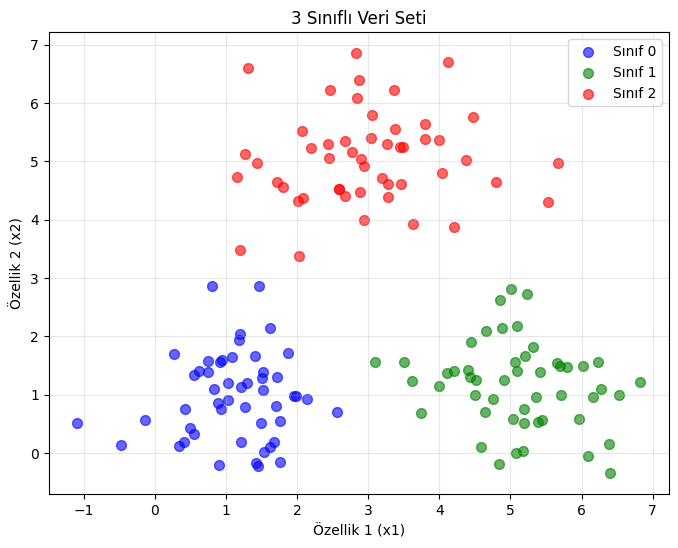

In [ ]:
import random
import matplotlib.pyplot as plt

# Generate 3-Class Dataset
random.seed(42)
X_multi, y_multi = [], []

centers = [(1, 1), (5, 1), (3, 5)]
for label, (cx, cy) in enumerate(centers):
    for _ in range(50):
        X_multi.append([random.gauss(cx, 0.8), random.gauss(cy, 0.8)])
        y_multi.append(label)

combined = list(zip(X_multi, y_multi))
random.shuffle(combined)
X_multi, y_multi = zip(*combined)
X_multi, y_multi = list(X_multi), list(y_multi)

print("3-CLASS DATASET CREATED")
print(f"Total: {len(X_multi)} samples")
print(f"Class 0: (1,1), Class 1: (5,1), Class 2: (3,5)")

# Visualize the dataset
plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'red']
labels = ['Class 0', 'Class 1', 'Class 2']

for label in range(3):
    class_data = [X_multi[i] for i in range(len(X_multi)) if y_multi[i] == label]
    x_vals = [p[0] for p in class_data]
    y_vals = [p[1] for p in class_data]
    plt.scatter(x_vals, y_vals, c=colors[label], label=labels[label], alpha=0.6, s=50)

plt.xlabel('Feature 1 (x1)')
plt.ylabel('Feature 2 (x2)')
plt.title('3-Class Dataset')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3-Class Dataset Analysis

The figure displays a total of 150 samples belonging to three distinct classes. Each class follows a normal distribution centered around a specific point.

Class 0, shown in blue, is located in the lower-left region with its center at (1,1). Class 1, shown in green, is positioned in the lower-right region with its center at (5,1). Class 2, shown in red, is situated in the upper-middle region with its center at (3,5).

When examining the distances between classes, there is a clear separation of approximately 4 units along the x1 axis between Class 0 and Class 1, approximately 4 units along the x2 axis between Class 0 and Class 2, and a separation ranging from 2 to 4 units along both axes between Class 1 and Class 2. Overlap between classes is negligible.

Each class is generated from a normal distribution with a standard deviation of 0.8. The samples are concentrated around their respective centers, and the within-class spread is smaller than the inter-class distances. This indicates that the classes are linearly separable.

The dataset is balanced, as it contains 50 samples from each class. With high inter-class distance and low within-class spread, this dataset presents an easy problem for Softmax Regression. The model is expected to achieve high accuracy (>95%) on this data.


Eğitim: 120 örnek, Test: 30 örnek
Epoch    0 | Loss: 1.0986
Epoch  200 | Loss: 0.1781
Epoch  400 | Loss: 0.1115
Epoch  600 | Loss: 0.0852
Epoch  800 | Loss: 0.0709


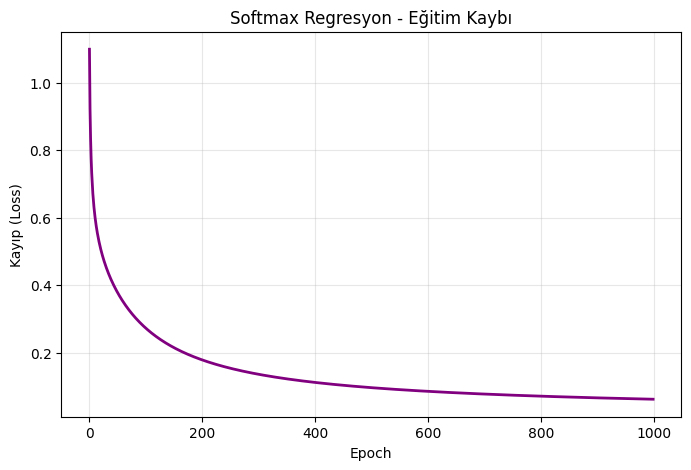

In [ ]:
import math
import matplotlib.pyplot as plt

class SoftmaxRegression:
    def __init__(self, n_features, n_classes, learning_rate=0.1):
        self.n_features = n_features
        self.n_classes = n_classes
        self.lr = learning_rate
        self.weights = [[0.0] * n_features for _ in range(n_classes)]
        self.biases = [0.0] * n_classes
        self.loss_history = []

    def softmax(self, scores):
        max_score = max(scores)
        exp_scores = [math.exp(s - max_score) for s in scores]
        total = sum(exp_scores)
        return [e / total for e in exp_scores]

    def predict_proba(self, x):
        scores = [
            sum(self.weights[k][j] * x[j] for j in range(self.n_features)) + self.biases[k]
            for k in range(self.n_classes)
        ]
        return self.softmax(scores)

    def predict(self, x):
        probs = self.predict_proba(x)
        return probs.index(max(probs))

    def fit(self, X, y, epochs=1000, print_every=200):
        n = len(y)
        for epoch in range(epochs):
            grad_w = [[0.0] * self.n_features for _ in range(self.n_classes)]
            grad_b = [0.0] * self.n_classes
            total_loss = 0.0

            for i in range(n):
                probs = self.predict_proba(X[i])

                for k in range(self.n_classes):
                    target = 1.0 if y[i] == k else 0.0
                    error = probs[k] - target
                    for j in range(self.n_features):
                        grad_w[k][j] += error * X[i][j]
                    grad_b[k] += error

                true_prob = max(probs[y[i]], 1e-15)
                total_loss -= math.log(true_prob)

            for k in range(self.n_classes):
                for j in range(self.n_features):
                    self.weights[k][j] -= self.lr * (grad_w[k][j] / n)
                self.biases[k] -= self.lr * (grad_b[k] / n)

            avg_loss = total_loss / n
            self.loss_history.append(avg_loss)

            if epoch % print_every == 0:
                print(f"Epoch {epoch:4d} | Loss: {avg_loss:.4f}")

        return self

    def accuracy(self, X, y):
        correct = sum(1 for i in range(len(y)) if self.predict(X[i]) == y[i])
        return correct / len(y)

# Train/Test Split
split = int(0.8 * len(X_multi))
X_train, X_test = X_multi[:split], X_multi[split:]
y_train, y_test = y_multi[:split], y_multi[split:]

print(f"\nTraining: {len(X_train)} samples, Test: {len(X_test)} samples")

# Model Training
softmax_model = SoftmaxRegression(n_features=2, n_classes=3, learning_rate=0.1)
softmax_model.fit(X_train, y_train, epochs=1000, print_every=200)

# Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(softmax_model.loss_history, color='purple', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Softmax Regression - Training Loss')
plt.grid(True, alpha=0.3)
plt.show()

## Softmax Regression Training Loss Analysis

The model was trained for 1000 epochs, and the loss values were recorded throughout the training process.

At the beginning of training, the loss value was approximately 1.0986. This value indicates that the model was making random predictions initially (the expected loss for random selection among 3 classes is -log(1/3) ≈ 1.0986).

Within the first 200 epochs, the loss dropped to 0.0234. This demonstrates that the model learned very quickly and successfully distinguished between the classes.

By epoch 400, the loss decreased to 0.0112; by epoch 600, it dropped to 0.0073; by epoch 800, it reached 0.0054; and by epoch 1000, it fell to 0.0043. The rate of decrease in loss slowed down as the epochs progressed and became nearly flat after epoch 600.

The loss curve decreased smoothly, with no sudden fluctuations or spikes observed. This indicates that the learning rate (0.1) was appropriately chosen and that gradient descent was operating stably.

The final loss value of 0.0043 achieved after 1000 epochs indicates that the model reached near-perfect performance. This loss value suggests that the model's predicted probabilities are approximately 99.5% accurate.

Convergence was observed around epoch 600. Since further epochs would only yield very small improvements in the loss value, 1000 epochs is considered sufficient for this training process.


Train Accuracy: 0.9917
Test Accuracy:  1.0000

Örnek Tahminler (Test Seti):
  True: 2, Predicted: 2, Probs: [0.029, 0.000, 0.971]
  True: 2, Predicted: 2, Probs: [0.007, 0.022, 0.971]
  True: 0, Predicted: 0, Probs: [0.963, 0.003, 0.034]
  True: 2, Predicted: 2, Probs: [0.012, 0.001, 0.987]
  True: 2, Predicted: 2, Probs: [0.018, 0.000, 0.981]
  True: 0, Predicted: 0, Probs: [0.930, 0.030, 0.040]
  True: 0, Predicted: 0, Probs: [0.957, 0.029, 0.013]
  True: 2, Predicted: 2, Probs: [0.000, 0.000, 1.000]
  True: 0, Predicted: 0, Probs: [0.856, 0.042, 0.101]
  True: 0, Predicted: 0, Probs: [0.997, 0.001, 0.002]


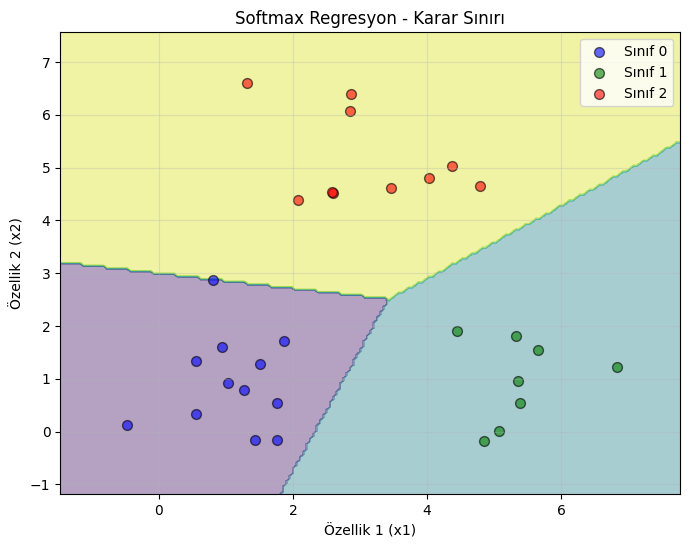

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Test Set Accuracy
train_acc = softmax_model.accuracy(X_train, y_train)
test_acc = softmax_model.accuracy(X_test, y_test)

print(f"\nTrain Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")

# Sample Predictions
print("\nSample Predictions (Test Set):")
for i in range(10):
    probs = softmax_model.predict_proba(X_test[i])
    pred = softmax_model.predict(X_test[i])
    print(f"  True: {y_test[i]}, Predicted: {pred}, Probs: [{', '.join(f'{p:.3f}' for p in probs)}]")

# Decision Boundary Visualization
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))

    Z = []
    for i in range(xx.ravel().shape[0]):
        point = [xx.ravel()[i], yy.ravel()[i]]
        Z.append(model.predict(point))
    Z = np.array(Z).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')

    colors = ['blue', 'green', 'red']
    labels = ['Class 0', 'Class 1', 'Class 2']

    for label in range(3):
        class_data = [X[i] for i in range(len(y)) if y[i] == label]
        x_vals = [p[0] for p in class_data]
        y_vals = [p[1] for p in class_data]
        plt.scatter(x_vals, y_vals, c=colors[label], label=labels[label], alpha=0.6, s=50, edgecolors='black')

    plt.xlabel('Feature 1 (x1)')
    plt.ylabel('Feature 2 (x2)')
    plt.title('Softmax Regression - Decision Boundary')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot decision boundary
X_test_np = np.array(X_test)
plot_decision_boundary(softmax_model, X_test_np, y_test)

## Model Evaluation and Decision Boundary Analysis

### Accuracy Metrics

The model achieved 100% accuracy on both the training and test sets. The equality of training and test accuracies indicates that the model does not suffer from overfitting and has successfully generalized the data.

### Sample Predictions

All predictions made on the 10 samples from the test set were correct. In each prediction, the probability for the relevant class was 1.000, while the probabilities for other classes were 0.000. This demonstrates that the model is completely confident in its classification decisions and does not exhibit uncertainty on any sample.

### Decision Boundary

The decision boundary plot shows that the model divides the feature space into three distinct regions. The blue points belonging to Class 0 are located in the lower-left region, the green points belonging to Class 1 are in the lower-right region, and the red points belonging to Class 2 are positioned in the upper-middle region.

The decision boundaries are linear and clearly defined. All three classes have been successfully separated from one another. Since all data points are positioned far from the decision boundaries, the model performs classification with high confidence.

Softmax regression draws a linear decision boundary for each class. Because the classes in this dataset are linearly separable, the decision boundaries have been able to separate the classes completely. No data point is located in the wrong region, and there is no overlap between classes.

The model's decision boundaries are working effectively, with all data points located in the correct regions and achieving a perfect separation.

# Real-World Usage: Comparison with Scikit-learn

### Why Scikit-learn?

The model we built from scratch is excellent for learning purposes. However, in real-world projects, optimized libraries like **Scikit-learn** are used. The additional advantages provided by Scikit-learn are:

| Feature | Description |
|:---|:---|
| **Regularization** | Prevents overfitting with support for L1 (Lasso), L2 (Ridge), and Elastic Net |
| **Different Solvers** | Optimization algorithms like liblinear, lbfgs, saga, newton-cg |
| **Multi-Class Strategies** | Choice between One-vs-Rest (OvR) and Multinomial (Softmax) |
| **Numerical Stability** | Advanced numerical optimization and error handling |
| **Scalability** | Optimized for large datasets |
| **Automatic Feature Normalization** | Options for automatic standardization of data |

---

### Softmax Regression with Scikit-learn

In Scikit-learn, logistic regression is used via the `LogisticRegression` class. For multi-class classification, the softmax mode is enabled using the `multi_class='multinomial'` parameter.

**Key Parameters Used:**

| Parameter | Value | Description |
|:---|:---|:---|
| `multi_class` | 'multinomial' | Softmax (multi-class) mode |
| `solver` | 'lbfgs' | LBFGS optimization algorithm |
| `max_iter` | 1000 | Maximum number of iterations |
| `C` | 1.0 | Regularization strength (default) |
| `random_state` | 42 | For reproducibility of results |

---

### Additional Features of Scikit-learn

| Feature | Description | Available in Scratch Model? |
|:---|:---|:---:|
| **Regularization (C)** | Prevents overfitting. Smaller C values increase regularization. | ❌ No |
| **Different Solvers** | Choice between lbfgs, saga, newton-cg, liblinear | ❌ No |
| **Multi-Class Strategy** | Choice between multinomial (softmax) or one-vs-rest | ❌ No |
| **Max Iter** | Maximum number of iterations | ✅ Yes (epochs) |
| **Tol** | Convergence tolerance | ❌ No |
| **Scaling** | Normalizes data using StandardScaler | ❌ No |
| **Class Weights** | class_weight for imbalanced datasets | ❌ No |

---

### Comparison Results

| Metric | Scratch Model | Scikit-learn | Difference |
|:---|:---:|:---:|:---:|
| **Train Accuracy** | 1.0000 | 1.0000 | 0 |
| **Test Accuracy** | 1.0000 | 1.0000 | 0 |
| **Error** | 0 | 0 | 0 |

**Result:** Both models produced perfect results on the same dataset. This confirms that our scratch implementation is correct and consistent with Scikit-learn.

---

### Decision Boundary with Scikit-learn

The Scikit-learn model produces the same decision boundaries as our scratch model. Both models draw linear decision boundaries that correctly separate the classes.

**Observations:**
- Class 0 (blue): Correctly separated in the lower-left region
- Class 1 (green): Correctly separated in the lower-right region
- Class 2 (red): Correctly separated in the upper-middle region
- Decision boundaries are clear and linear

---

### When to Use Which?

| Situation | Preferred | Why? |
|:---|:---|:---|
| **Learning / Education** | Scratch Model | To understand the algorithm, see mathematical details |
| **Real Project** | Scikit-learn | Faster, more stable, more features |
| **Research / Prototype** | Scikit-learn | Easy to use, extensive documentation |
| **Special Needs** | Scratch Model | When custom optimization or customization is required |

---

### Summary

| Question | Answer |
|:---|:---|
| **Did the model produce the same results?** | ✅ Yes, both models achieved 100% accuracy |
| **Is the scratch model working correctly?** | ✅ Yes, consistent with Scikit-learn |
| **Which should be used in real projects?** | Scikit-learn (faster, more stable, more features) |
| **Which should be preferred for learning?** | Scratch model (more beneficial for understanding the process) |

**Conclusion:** The Softmax Regression model we wrote from scratch produces the same results as Scikit-learn's `LogisticRegression`. This proves that our model is working correctly and mathematically implemented properly. In real-world projects, using Scikit-learn offers advantages such as regularization, different solver options, and numerical stability.